### This notebook extract newly generated molecules after the DORAnet run: 

In [1]:
import os
import io
import re
import math
import json
import glob
import base64
from io import BytesIO
from pathlib import Path
from collections import defaultdict, deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem, Descriptors, Draw, QED, rdMolDescriptors
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.SimDivFilters.rdSimDivPickers import MaxMinPicker

from PIL import Image, ImageDraw, ImageFont
from IPython.display import HTML, display, SVG

RDLogger.DisableLog('rdApp.*')

from DORA_XGB import DORA_XGB
by_desc_MW_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'by_descending_MW')
by_asc_MW_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'by_ascending_MW')
add_concat_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'add_concat')
add_subtract_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'add_subtract')

/users/sghosh6/.conda/envs/doranet_env/lib/python3.10/site-packages/xgboost/compat.py:105: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
fileNamePrefix = "BrincidofovirOnly_gen2"

In [3]:
def canonSmiles(smi):
    mol = Chem.MolFromSmiles(str(smi))
    return Chem.MolToSmiles(mol) if mol else str(smi)

### generate `max_atoms` configuration

In [4]:
starterSMILES = 'CCCCCCCCCCCCCCCCOCCCOP(=O)(CO[C@@H](CN1C=CC(=NC1=O)N)CO)O'
doranet_generations = 2

mol = Chem.MolFromSmiles(starterSMILES)
counts = {"C": 0, "N": 0, "O": 0, "S": 0}

for atom in mol.GetAtoms():
    sym = atom.GetSymbol()
    if sym in counts:
        counts[sym] += 1

print("Atom counts:", counts)

max_atoms = {k: math.ceil(v * 1.5) for k, v in counts.items()}
print("Recommended max_atoms:", max_atoms)

Atom counts: {'C': 27, 'N': 3, 'O': 7, 'S': 0}
Recommended max_atoms: {'C': 41, 'N': 5, 'O': 11, 'S': 0}


### Discover All Starter Directories

In [5]:
doranetOutputDir = "doranet_output"

helpersToExclude = {
    'O', 'O=O', '[H][H]', 'O=C=O', 'C=O', '[C-]#[O+]', 'Br', '[Br][Br]',
    'CO', 'C=C', 'O=S(O)O', 'N', 'O=S(=O)(O)O', 'O=NO', 'N#N',
    'O=[N+]([O-])O', 'NO', 'C#N', 'S', 'O=S=O', 'N#CO', '[H+]', 'OO',
    'Cl', 'I', 'O=C(O)O', 'O=P(O)(O)O', 'O=P(O)(O)OP(=O)(O)O', 'C',
    'CC', 'CC=O', 'CC(=O)O', 'CCC(=O)O'
}

print(f"Output directory: {doranetOutputDir}")
print(f"Number of helpers to exclude: {len(helpersToExclude)}")

Output directory: doranet_output
Number of helpers to exclude: 33


In [6]:
# Automatically find all *_molecules.csv files in the current working directory
currentDir = os.getcwd()

allMoleculesCsvFiles = sorted(glob.glob(os.path.join(currentDir, "*_molecules.csv")))

print(f"Found {len(allMoleculesCsvFiles)} molecules CSV files in current directory")

# Parse discovered CSV files
discoveredCsvFiles = []

for csvPath in allMoleculesCsvFiles:
    fileName = os.path.basename(csvPath)
    dirName = fileName.replace('_molecules.csv', '')
    
    try:
        starterNum = int(dirName.replace('starter_', ''))
    except ValueError:
        starterNum = -1  # For non-standard naming

    discoveredCsvFiles.append({
        'dirName': dirName,
        'dirPath': currentDir,
        'csvPath': csvPath,
        'starterNum': starterNum
    })

# Sort by starter number
discoveredCsvFiles.sort(key=lambda x: x['starterNum'])

print(f"Found {len(discoveredCsvFiles)} CSV files containing DORAnet generated molecules")

Found 1 molecules CSV files in current directory
Found 1 CSV files containing DORAnet generated molecules


### Extract the `DORAnet` starter molecule

In [7]:
user_starters = set()
starterReadErrors = []

for fileInfo in discoveredCsvFiles:
    try:
        # Read only the SMILES and Is_Starter columns to save memory
        tempDF = pd.read_csv(
            fileInfo['csvPath'],
            usecols=['SMILES', 'Is_Starter']
        )
        starterSmiles = (
            tempDF[tempDF['Is_Starter'] == True]['SMILES']
            .dropna()
            .tolist()
        )
        user_starters.update(starterSmiles)

    except Exception as e:
        starterReadErrors.append({
            'dirName': fileInfo['dirName'],
            'csvPath': fileInfo['csvPath'],
            'error': str(e)
        })

if len(user_starters) == 0:
    raise ValueError("No starter molecules found across any CSV files!")

print(f"Number of unique starter molecules found: {len(user_starters)}")
for i, smi in enumerate(user_starters, 1):
    print(f"  Starter {i}: {smi}")

if starterReadErrors:
    print(f"\nFailed to read {len(starterReadErrors)} files:")
    for err in starterReadErrors:
        print(f"  {err['dirName']}: {err['error']}")

Number of unique starter molecules found: 1
  Starter 1: CCCCCCCCCCCCCCCCOCCCOP(=O)(CO[C@@H](CN1C=CC(=NC1=O)N)CO)O


Starter 01: CCCCCCCCCCCCCCCCOCCCOP(=O)(CO[C@@H](CN1C=CC(=NC1=O)N)CO)O


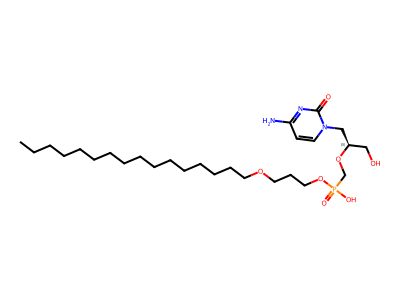

In [8]:
from IPython.display import display, SVG

invalidSmiles = []

for i, smi in enumerate(user_starters, 1):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        invalidSmiles.append(smi)
        continue

    for fmt, drawClass, ext in [
        ("svg", rdMolDraw2D.MolDraw2DSVG, "svg"),
        ("png", rdMolDraw2D.MolDraw2DCairo, "png"),
    ]:
        drawer = drawClass(400, 300)
        drawer.drawOptions().addStereoAnnotation = True
        drawer.DrawMolecule(mol)
        drawer.FinishDrawing()

        savePath = os.path.join(f"{fileNamePrefix}_starter_{i:02d}.{ext}")
        if fmt == "svg":
            with open(savePath, "w") as f:
                f.write(drawer.GetDrawingText())
        else:
            with open(savePath, "wb") as f:
                f.write(drawer.GetDrawingText())

    print(f"Starter {i:02d}: {smi}")
    display(SVG(drawer.GetDrawingText() if fmt == "svg" else
                open(os.path.join(f"{fileNamePrefix}_starter_{i:02d}.svg")).read()))

if invalidSmiles:
    print(f"\nCould not parse {len(invalidSmiles)} SMILES:")
    for smi in invalidSmiles:
        print(f"  {smi}")

### Read `reaction_strings` from the `DORAnet` generated `json` file

In [9]:
jsonFile = f"{fileNamePrefix}_network_pretreated.json"

with open(jsonFile, "r", encoding="utf-8") as f:
    reactionList = json.load(f)

def splitMoleculeString(moleculeString):
    if pd.isna(moleculeString) if hasattr(pd, 'isna') else moleculeString is None:
        return []
    return [mol for mol in str(moleculeString).split(".") if mol]

reactionRecords = []

for rxn in reactionList:
    parts = str(rxn).split(">")
    if len(parts) != 4:
        continue

    reactants, ruleName, metaBlock, products = parts
    metaParts      = (metaBlock.split("$") + [None, None, None, None])[:4]
    thermo, reactantStoich, productStoich, reactionType = metaParts

    reactantMols = splitMoleculeString(reactants.strip())
    productMols  = splitMoleculeString(products.strip())

    reactionRecords.append({
        "reactants"            : reactants.strip(),
        "products"             : products.strip(),
        "reactionString"       : f"{reactants.strip()} >> {products.strip()}",
        "ruleName"             : ruleName.strip(),
        "thermo"               : thermo,
        "reactantStoich"       : reactantStoich,
        "productStoich"        : productStoich,
        "reactionType"         : reactionType,
        "numReactantMolecules" : len(reactantMols),
        "numProductMolecules"  : len(productMols),
    })

reactionDF = pd.DataFrame(reactionRecords)

allReactantMols = reactionDF["reactants"].apply(splitMoleculeString).explode()
allProductMols  = reactionDF["products"].apply(splitMoleculeString).explode()

print(f"Total reactions                      : {len(reactionDF):,}")
print(f"Unique reactant strings              : {reactionDF['reactants'].nunique():,}")
print(f"Unique product strings               : {reactionDF['products'].nunique():,}")
print(f"Unique individual reactant molecules : {allReactantMols.nunique():,}")
print(f"Unique individual product molecules  : {allProductMols.nunique():,}")
print(f"Unique reaction rules                : {reactionDF['ruleName'].nunique():,}")
print(f"reactionType counts:")
print(reactionDF["reactionType"].value_counts(dropna=False).to_string())

reactionDF.to_csv("reactionDF.csv", index=False)
reactionDF

Total reactions                      : 682,585
Unique reactant strings              : 12,544
Unique product strings               : 534,150
Unique individual reactant molecules : 760
Unique individual product molecules  : 289,459
Unique reaction rules                : 182
reactionType counts:
reactionType
Enzymatic    682585


,reactants,products,reactionString,ruleName,thermo,reactantStoich,productStoich,reactionType,numReactantMolecules,numProductMolecules
0,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)C(CCCCCCCCCCC)O[C...,CCCCCCCCCCCCCCCCOCC(C)COP(=O)(O)C(CCCCCCCCCCC)...,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)C(CCCCCCCCCCC)O[C...,rule0126_2,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2
1,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1c(C...,CCCCCCCCCCCCOCCCOP(=O)(O)CO[C@@H](Cn1c(CCCCCCC...,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1c(C...,rule0028_51,No_Thermo,"(1,)","(1,)",Enzymatic,1,1
2,CCCCCC(C)CCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1c...,CCCCCC(C)CCCCCCCC(CCOCC)OP(=O)(O)CO[C@H](CO)Cn...,CCCCCC(C)CCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1c...,rule0028_51,No_Thermo,"(1,)","(1,)",Enzymatic,1,1
3,CCCCCCCCC(CC)CCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1c...,CCCCCCCC(CC)CCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1cc...,CCCCCCCCC(CC)CCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1c...,rule0126_2,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2
4,CCCCCCCC(CCCCCCC)CCCCCCCCOCCCOP(=O)(O)CO[C@H](...,CCCCCCCC(CCC)CCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)C...,CCCCCCCC(CCCCCCC)CCCCCCCCOCCCOP(=O)(O)CO[C@H](...,rule0126_2,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2
...,...,...,...,...,...,...,...,...,...,...
682580,CCCCCCCC(C)CCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](...,CCCCCCCC(C)CCCCCCCCC(CCOP(=O)(O)CO[C@H](CO)Cn1...,CCCCCCCC(C)CCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](...,rule0028_51,No_Thermo,"(1,)","(1,)",Enzymatic,1,1
682581,CCCCCCCCCCCCCC(CCCC)CCCCCCCCCCCOCCCOP(=O)(O)CO...,CCCCCCCC(CCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc(...,CCCCCCCCCCCCCC(CCCC)CCCCCCCCCCCOCCCOP(=O)(O)CO...,rule0028_51,No_Thermo,"(1,)","(1,)",Enzymatic,1,1
682582,CCCCCCCCCCCCCCCCOCCC(CCCCCCCC)OP(=O)(O)CO[C@H]...,CCCCCCCCCCCCCCCCOCCC(CCCCCC)OP(=O)(O)CO[C@H](C...,CCCCCCCCCCCCCCCCOCCC(CCCCCCCC)OP(=O)(O)CO[C@H]...,rule0126_2,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2
682583,CCCCCCCCCCCCC(C)CCCCCCCCCCCCCCOCCCOP(=O)(O)CO[...,CCCCCCCCCCCCC(C)CCCCCCC(CCCCCCC)OCCCOP(=O)(O)C...,CCCCCCCCCCCCC(C)CCCCCCCCCCCCCCOCCCOP(=O)(O)CO[...,rule0028_51,No_Thermo,"(1,)","(1,)",Enzymatic,1,1


### `Method-2`: Filter compounds based on Starter scaffold matching

In [10]:
DORAnet_CoFactors = "/users/sghosh6/DTRA_project/MACAW/doranet/scripts/doranet_all_cofactors.tsv"

_cofactorTable = pd.read_csv(DORAnet_CoFactors, sep="\t")
_cofactorTable.columns = [col.lstrip("#").strip() for col in _cofactorTable.columns]

COFACTOR_SMILES = [
    Chem.MolToSmiles(mol)
    for smi in _cofactorTable["SMILES"].dropna()
    if (mol := Chem.MolFromSmiles(str(smi))) is not None
]
print(f"{len(COFACTOR_SMILES)} Co-factors for enzymatic reactions loaded from DORAnet database.")

46 Co-factors for enzymatic reactions loaded from DORAnet database.


In [ ]:
import base64
from io import BytesIO
from rdkit import DataStructs
from rdkit.Chem import rdMolDescriptors, Draw
from IPython.display import HTML, display

fpRadius, fpBits = 2, 2048

# Lipinski rule of five: 0 = compound must satisfy all four criteria;
# set to 1 for the classic "no more than one violation" form.
lipinskiMaxViolations = 0

def morganFp(mol):
    return rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, fpRadius, nBits=fpBits) if mol is not None else None


physicochemicalCutoffs = {
    "mwMax"  : 700.0,
    "tpsaMax": 200.0,
    "hbdMax" : 7,
    "qedMin" : 0.10,
}


def buildCofactorExclusionSet(rawSmilesList):
    exclusionSet = set()
    for smi in rawSmilesList:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            exclusionSet.add(Chem.MolToSmiles(mol))
        else:
            print(f"  Warning: could not parse cofactor SMILES: {smi}")
    print(f"Cofactor exclusion set built: {len(exclusionSet)} entries resolved.")
    return exclusionSet


def isCofactorOrEndogenous(mol, canonSmi, cofactorExclusionSet, cutoffs):
    if mol is None:
        return True
    if canonSmi in cofactorExclusionSet:
        return True
    mw   = Descriptors.MolWt(mol)
    tpsa = rdMolDescriptors.CalcTPSA(mol)
    hbd  = rdMolDescriptors.CalcNumHBD(mol)
    if mw > cutoffs["mwMax"] or tpsa > cutoffs["tpsaMax"] or hbd > cutoffs["hbdMax"]:
        return True
    qed = QED.qed(mol)
    if qed < cutoffs["qedMin"]:
        return True
    return False


def lipinskiViolationCount(mol):
    if mol is None:
        return None
    violations = 0
    if Descriptors.MolWt(mol)           > 500:
        violations += 1
    if Descriptors.MolLogP(mol)         > 5:
        violations += 1
    if rdMolDescriptors.CalcNumHBD(mol) > 5:
        violations += 1
    if rdMolDescriptors.CalcNumHBA(mol) > 10:
        violations += 1
    return violations


def passesLipinski(canonSmi, maxViolations):
    violations = lipinskiViolationCount(Chem.MolFromSmiles(str(canonSmi)))
    return violations is not None and violations <= maxViolations


def preservesStarterScaffold(compoundMol, starterCanon, canonToStarterMol):
    starterMol = canonToStarterMol.get(starterCanon)
    if starterMol is None:
        starterMol = Chem.MolFromSmiles(str(starterCanon))
    if starterMol is None or compoundMol is None:
        return False
    return compoundMol.HasSubstructMatch(starterMol)


def starterSimilarityRange(mol, starterFpByCanon):
    productFp = morganFp(mol)
    if productFp is None or not starterFpByCanon:
        return None, None
    sims = [DataStructs.TanimotoSimilarity(productFp, starterFp) for starterFp in starterFpByCanon.values()]
    return max(sims), min(sims)


def nearestStarterBySimilarity(mol, starterFpByCanon):
    productFp = morganFp(mol)
    if productFp is None or not starterFpByCanon:
        return None, -1.0
    bestStarter    = None
    bestSimilarity = -1.0
    for starterCanon, starterFp in starterFpByCanon.items():
        similarity = DataStructs.TanimotoSimilarity(productFp, starterFp)
        if similarity > bestSimilarity:
            bestSimilarity = similarity
            bestStarter    = starterCanon
    return bestStarter, bestSimilarity


def molToImgTag(smi, size=(200, 150)):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return ""
    img = Draw.MolToImage(mol, size=size)
    buffer = BytesIO()
    img.save(buffer, format="PNG")
    encoded = base64.b64encode(buffer.getvalue()).decode("utf-8")
    return f'<img src="data:image/png;base64,{encoded}"/>'

def buildStarterDerivedSet(reactionDF, starterMols, canonStarterSet,
                           canonHelperSet, cofactorExclusionSet, cutoffs,
                           starterFpByCanon):
    molToReactionIdxs = defaultdict(list)
    for idx, row in reactionDF.iterrows():
        for smi in splitMoleculeString(row["reactants"]):
            molToReactionIdxs[canonSmiles(smi)].append(idx)

    # Value: (matchedStarter, generationDepth, keptSimilarity, runnerUpSimilarity)
    starterDerivedSet = {canonSmi: (canonSmi, 0, 1.0, None) for canonSmi, _ in starterMols}
    queue   = deque((canonSmi, 0) for canonSmi in canonStarterSet)
    visited = set(canonStarterSet)

    while queue:
        currentCanon, currentDepth = queue.popleft()

        if currentCanon in canonHelperSet:
            continue

        for rxnIdx in molToReactionIdxs.get(currentCanon, []):
            row = reactionDF.loc[rxnIdx]

            # Score every eligible product of this reaction against its nearest starter
            productScores = []
            for productSmi in splitMoleculeString(row["products"]):
                productCanon = canonSmiles(productSmi)

                if productCanon in canonHelperSet:
                    continue
                if productCanon in starterDerivedSet:
                    continue

                productMol = Chem.MolFromSmiles(str(productSmi))

                if isCofactorOrEndogenous(productMol, productCanon,
                                          cofactorExclusionSet, cutoffs):
                    continue

                matchedStarter, similarity = nearestStarterBySimilarity(productMol, starterFpByCanon)
                if matchedStarter is None:
                    continue

                productScores.append((similarity, productCanon, matchedStarter))

            if not productScores:
                continue

            # Highest-similarity product is kept; the next one is the runner-up
            productScores.sort(key=lambda t: t[0], reverse=True)
            keptSimilarity, bestProductCanon, bestMatchedStarter = productScores[0]
            runnerUpSimilarity = productScores[1][0] if len(productScores) > 1 else None

            if bestProductCanon not in visited:
                visited.add(bestProductCanon)
                starterDerivedSet[bestProductCanon] = (
                    bestMatchedStarter, currentDepth + 1, keptSimilarity, runnerUpSimilarity
                )
                queue.append((bestProductCanon, currentDepth + 1))

    return starterDerivedSet

cofactorExclusionSet = buildCofactorExclusionSet(COFACTOR_SMILES)

starterMols = [
    (canonSmiles(smi), Chem.MolFromSmiles(str(smi)))
    for smi in user_starters
    if Chem.MolFromSmiles(str(smi)) is not None
]
canonStarterSet   = {s for s, _ in starterMols}
canonHelperSet    = {canonSmiles(s) for s in helpersToExclude}
canonToStarterMol = {canonStarter: starterMol for canonStarter, starterMol in starterMols}
starterFpByCanon  = {
    canonStarter: morganFp(starterMol)
    for canonStarter, starterMol in starterMols
    if morganFp(starterMol) is not None
}

print("Running forward BFS tracing through reaction network...")
starterDerivedSet = buildStarterDerivedSet(
    reactionDF,
    starterMols,
    canonStarterSet,
    canonHelperSet,
    cofactorExclusionSet = cofactorExclusionSet,
    cutoffs              = physicochemicalCutoffs,
    starterFpByCanon     = starterFpByCanon,
)
print(f"Starter-derived molecules found (including starters): {len(starterDerivedSet):,}")

uniqueProductMolsList = allProductMols.dropna().unique().tolist()

productRecords         = []
excludedCofactorSmiles = []
excludedHelper         = 0
excludedStarter        = 0
excludedCofactor       = 0
excludedNonDerived     = 0

for smi in uniqueProductMolsList:
    mol      = Chem.MolFromSmiles(str(smi))
    canonSmi = Chem.MolToSmiles(mol) if mol else None

    if canonSmi is None:
        continue
    if canonSmi in canonHelperSet:
        excludedHelper += 1
        continue
    if canonSmi in canonStarterSet:
        excludedStarter += 1
        continue
    if isCofactorOrEndogenous(mol, canonSmi, cofactorExclusionSet, physicochemicalCutoffs):
        excludedCofactor += 1
        excludedCofactorSmiles.append(canonSmi)
        continue
    if canonSmi not in starterDerivedSet:
        excludedNonDerived += 1
        continue

    matchedRaw, generationDepth, keptSimilarity, runnerUpSimilarity = starterDerivedSet.get(
        canonSmi, (None, None, None, None)
    )
    starterCanonicalSmiles = canonSmiles(matchedRaw) if matchedRaw else None

    productRecords.append({
        "starter_Canonical_SMILES" : starterCanonicalSmiles,
        "Canonical_SMILES"         : canonSmi,
        "generationSteps"          : generationDepth,
        "DerivativeSimScore"       : round(keptSimilarity, 4) if keptSimilarity is not None else None,
        "NonDerivativeSimScore"    : round(runnerUpSimilarity, 4) if runnerUpSimilarity is not None else None,
        "_molecularWeight"         : round(Descriptors.MolWt(mol), 4),
    })

generatedCompoundsDfRaw = pd.DataFrame(productRecords)

nBeforeDedup = len(generatedCompoundsDfRaw)

generatedCompoundsDfDedup = (
    generatedCompoundsDfRaw
    .drop_duplicates(subset="Canonical_SMILES", keep="first")
    .reset_index(drop=True)
)
nAfterDedup = len(generatedCompoundsDfDedup)

# Keep only compounds that satisfy Lipinski's rule of five
lipinskiMask = generatedCompoundsDfDedup["Canonical_SMILES"].apply(
    lambda s: passesLipinski(s, lipinskiMaxViolations)
)
generatedCompoundsDfLipinski = generatedCompoundsDfDedup[lipinskiMask].reset_index(drop=True)
nAfterLipinski = len(generatedCompoundsDfLipinski)

# Sort by descending molecular weight, then drop the helper weight column
generatedCompoundsDF = (
    generatedCompoundsDfLipinski
    .sort_values("_molecularWeight", ascending=False)
    .drop(columns="_molecularWeight")
    .reset_index(drop=True)
)

# Candidate list ordered by descending molecular weight
generatedCompoundsList = generatedCompoundsDF["Canonical_SMILES"].tolist()

# Scaffold preservation computed only for reporting (not stored in the frame or CSV)
scaffoldFlags = generatedCompoundsDF.apply(
    lambda r: preservesStarterScaffold(
        Chem.MolFromSmiles(str(r["Canonical_SMILES"])),
        r["starter_Canonical_SMILES"],
        canonToStarterMol,
    ),
    axis=1,
)
nDerivative    = int(scaffoldFlags.sum())
nNonDerivative = int((~scaffoldFlags).sum())

# Save the clean SMILES/score table before adding structure images
generatedCompoundsCsvPath = f"{fileNamePrefix}_generated_compounds.csv"
generatedCompoundsDF.to_csv(generatedCompoundsCsvPath, index=False)

print(f"Unique product molecules total        : {len(uniqueProductMolsList):,}")
print(f"Excluded as helpers                   : {excludedHelper:,}")
print(f"Excluded as starters                  : {excludedStarter:,}")
print(f"Excluded as cofactors / endogenous    : {excludedCofactor:,}")
print(f"Excluded as non-derived               : {excludedNonDerived:,}")
print(f"Compounds before deduplication        : {nBeforeDedup:,}")
print(f"Compounds after deduplication         : {nAfterDedup:,}")
print(f"Compounds after Lipinski rule of 5    : {nAfterLipinski:,}")
print(f"Removed by Lipinski filter            : {nAfterDedup - nAfterLipinski:,}")
print(f"Scaffold-preserving (Derivative)      : {nDerivative:,}")
print(f"Scaffold-modified (Non-derivative)    : {nNonDerivative:,}")
print(f"\nGeneration-step distribution:")
print(generatedCompoundsDF["generationSteps"].value_counts(dropna=False).sort_index().to_string())
print(f"\nCandidates in list (descending MW)    : {len(generatedCompoundsList):,}")
print(f"\nSaved to: {generatedCompoundsCsvPath}")
'''
# Add rendered structures for inline display (not written to the CSV)
generatedCompoundsDF["starterStructure"] = generatedCompoundsDF["starter_Canonical_SMILES"].apply(molToImgTag)
generatedCompoundsDF["productStructure"] = generatedCompoundsDF["Canonical_SMILES"].apply(molToImgTag)

displayColumns = [
    "starter_Canonical_SMILES", "starterStructure",
    "Canonical_SMILES", "productStructure",
    "generationSteps", "DerivativeSimScore", "NonDerivativeSimScore",
]
generatedCompoundsDF = generatedCompoundsDF[displayColumns]

display(HTML(generatedCompoundsDF.head(10).to_html(escape=False)))
'''

Cofactor exclusion set built: 43 entries resolved.
Running forward BFS tracing through reaction network...


In [ ]:
multiProductRows = generatedCompoundsDF[generatedCompoundsDF["NonDerivativeSimScore"].notna()]

print(f"Rows with more than one eligible product: {len(multiProductRows):,} of {len(generatedCompoundsDF):,}")

cols = ["starter_Canonical_SMILES", "Canonical_SMILES",
        "generationSteps", "DerivativeSimScore", "NonDerivativeSimScore"]
multiProductRows[cols].head(5)

# Use `DORA-XGB` to get feasibility score

In [ ]:
reactionDF_DORAXGB = pd.read_csv("reactionDF_wDORAXGBfeasibility.csv")
reactionDF_DORAXGB

### Keep only `high feasible` reactions

In [ ]:
feasibilityLabels = [
    "feasibilityLabel_rule1",
    "feasibilityLabel_rule2",
    "feasibilityLabel_rule3",
    "feasibilityLabel_rule4",
]
targetValue      = 1
chosenLabel      = "feasibilityLabel_rule3"   # add_concat (rule3): the published DORA-XGB model

for lbl in feasibilityLabels:
    if lbl not in reactionDF_DORAXGB.columns:
        raise KeyError(f"Column '{lbl}' not found in reactionDF_DORAXGB")
if chosenLabel not in feasibilityLabels:
    raise KeyError(f"chosenLabel '{chosenLabel}' is not in feasibilityLabels")

results = {}
for feasibilityLabel in feasibilityLabels:
    high_df = reactionDF_DORAXGB[
        (reactionDF_DORAXGB[feasibilityLabel] == targetValue)
        & (reactionDF_DORAXGB[feasibilityLabel].notna())
    ].sort_values(by=feasibilityLabel, ascending=False).reset_index(drop=True)
    results[feasibilityLabel] = {"count_high": len(high_df), "df": high_df}

print(f"Target value considered as highly feasible: {targetValue}")
for lbl in feasibilityLabels:
    print(f"{lbl}: {results[lbl]['count_high']} highly feasible reactions")

best_rule                            = chosenLabel
bestRuleScoreCol                     = best_rule.replace("Label", "Score")   # needed for pathway scoring below
reactionDF_DORAXGB_highFeasibility   = results[best_rule]["df"]
print(f"\nChosen feasibility label: {best_rule} == {targetValue}")
print(f"Number of high-feasibility reactions: {len(reactionDF_DORAXGB_highFeasibility)}")

### Filter compounds which generated from `starter` scaffold + also DORA-XGB `high-feasibility` reactions

In [ ]:
def ensureReactantProductCols(df):
    df = df.copy()
    if "reactants" in df.columns and "products" in df.columns:
        return df.reset_index(drop=True)
    if "reactionString" in df.columns:
        sides = df["reactionString"].astype(str).str.split(">>", n=1, expand=True)
        df["reactants"] = sides[0].str.replace(" ", "", regex=False)
        df["products"]  = sides[1].str.replace(" ", "", regex=False)
        return df.reset_index(drop=True)
    raise KeyError("reactionDF_DORAXGB needs 'reactants'/'products' or 'reactionString' columns")

reactionDF_highFeasible = ensureReactantProductCols(
    reactionDF_DORAXGB[
        (reactionDF_DORAXGB[chosenLabel] == targetValue)
        & (reactionDF_DORAXGB[chosenLabel].notna())
    ]
)
print(f"High-feasibility reactions ({chosenLabel} == {targetValue}): "
      f"{len(reactionDF_highFeasible):,} of {len(reactionDF_DORAXGB):,}")

# forward BFS through the high-feasibility network only
starterDerivedSet_highFeasibility = buildStarterDerivedSet(
    reactionDF_highFeasible,
    starterMols,
    canonStarterSet,
    canonHelperSet,
    cofactorExclusionSet = cofactorExclusionSet,
    cutoffs              = physicochemicalCutoffs,
    starterFpByCanon     = starterFpByCanon,
)
print(f"Starter-derived via high-feasibility paths (incl. starters): "
      f"{len(starterDerivedSet_highFeasibility):,}")

# product universe of the high-feasibility network
highFeasibleProductMols = reactionDF_highFeasible["products"].apply(splitMoleculeString).explode()
uniqueHighFeasibleProducts = highFeasibleProductMols.dropna().unique().tolist()

def enumerateStarterDerivedProducts(uniqueProductList, starterDerivedSet):
    records = []
    for smi in uniqueProductList:
        mol      = Chem.MolFromSmiles(str(smi))
        canonSmi = Chem.MolToSmiles(mol) if mol else None
        if canonSmi is None:
            continue
        if canonSmi in canonHelperSet:
            continue
        if canonSmi in canonStarterSet:
            continue
        if isCofactorOrEndogenous(mol, canonSmi, cofactorExclusionSet, physicochemicalCutoffs):
            continue
        if canonSmi not in starterDerivedSet:
            continue
        matchedRaw, generationDepth, keptSimilarity, runnerUpSimilarity = starterDerivedSet.get(
            canonSmi, (None, None, None, None)
        )
        records.append({
            "starter_Canonical_SMILES": canonSmiles(matchedRaw) if matchedRaw else None,
            "Canonical_SMILES"        : canonSmi,
            "generationSteps"         : generationDepth,
            "DerivativeSimScore"      : round(keptSimilarity, 4) if keptSimilarity is not None else None,
            "NonDerivativeSimScore"   : round(runnerUpSimilarity, 4) if runnerUpSimilarity is not None else None,
            "_molecularWeight"        : round(Descriptors.MolWt(mol), 4),
        })
    return pd.DataFrame(records)

rawHighFeasible = enumerateStarterDerivedProducts(
    uniqueHighFeasibleProducts, starterDerivedSet_highFeasibility
)

dedupHighFeasible = (
    rawHighFeasible
    .drop_duplicates(subset="Canonical_SMILES", keep="first")
    .reset_index(drop=True)
)
lipinskiMaskHighFeasible = dedupHighFeasible["Canonical_SMILES"].apply(
    lambda s: passesLipinski(s, lipinskiMaxViolations)
)
lipinskiHighFeasible = dedupHighFeasible[lipinskiMaskHighFeasible].reset_index(drop=True)

generatedCompoundsDF_highFeasibility = (
    lipinskiHighFeasible
    .sort_values("_molecularWeight", ascending=False)
    .drop(columns="_molecularWeight")
    .reset_index(drop=True)
)

# Preserve the step length assigned by generatedCompoundsDF (full-network generation depth)
# instead of the longer depths the sparser high-feasibility subnetwork recomputes.
originalStepsByCompound = (
    generatedCompoundsDF
    .drop_duplicates("Canonical_SMILES")
    .set_index("Canonical_SMILES")["generationSteps"]
)
generatedCompoundsDF_highFeasibility["generationSteps"] = (
    generatedCompoundsDF_highFeasibility["Canonical_SMILES"].map(originalStepsByCompound)
)

missingSteps = int(generatedCompoundsDF_highFeasibility["generationSteps"].isna().sum())
if missingSteps:
    print(f"Warning: {missingSteps} compounds not found in generatedCompoundsDF; generationSteps is NaN")

generatedCompoundsList_highFeasibility = (
    generatedCompoundsDF_highFeasibility["Canonical_SMILES"].tolist()
)

outPathHighFeasible = f"{fileNamePrefix}_generated_compounds_highFeasibility.csv"
generatedCompoundsDF_highFeasibility.to_csv(outPathHighFeasible, index=False)

stepCounts = (
    generatedCompoundsDF_highFeasibility["generationSteps"]
    .value_counts(dropna=False)
    .sort_index()
)
print("\nHigh-feasibility candidates by generation steps:")
for nSteps, count in stepCounts.items():
    print(f"  {nSteps}-step : {count:,}")

print(f"Compounds before deduplication         : {len(rawHighFeasible):,}")
print(f"After deduplication                    : {len(dedupHighFeasible):,}")
print(f"After Lipinski rule of 5               : {len(lipinskiHighFeasible):,}")
print(f"\nCandidates in list (descending MW)     : {len(generatedCompoundsList_highFeasibility):,}")
print(f"Saved to: {outPathHighFeasible}")

### Plot pathways

In [ ]:
from collections import defaultdict, deque
import os

# CONFIG
numToDisplayPerStep = 4
saveFigures         = False
figureOutDir        = "."
subImgSize          = (600, 300)
articleFiguresDir     = "PathwayFigures"
rulesetPath           = "/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/DORAnet/JN3604IMT_rules.tsv"
cofactorTablePath     = "/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/DORAnet/all_cofactors.tsv"

cofactorDisplayOverride = {
    "CO-A": "CoA", "ACETYL-COA": "Acetyl-CoA", "OXYGEN-MOLECULE": "O2",
    "WATER": "H2O", "HYDROGEN-PEROXIDE": "H2O2", "CARBON-DIOXIDE": "CO2",
    "AMMONIA": "NH3", "S-ADENOSYLMETHIONINE": "SAM", "ADENOSYL-HOMO-CYS": "SAH",
    "2-KETOGLUTARATE": "2-Ketoglutarate", "GLT": "Glutamate", "PROTON": "H+",
}

def loadFont(size):
    for path in [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
        "/usr/share/fonts/truetype/freefont/FreeSansBold.ttf",
    ]:
        try:
            return ImageFont.truetype(path, size)
        except Exception:
            continue
    return ImageFont.load_default()

separatorFont = loadFont(52)
labelFont     = loadFont(18)
headerFont    = loadFont(22)

def canonicalizeSmiles(smi):
    mol = Chem.MolFromSmiles(str(smi))
    return Chem.MolToSmiles(mol) if mol else str(smi)

def cofactorKey(smi):
    mol = Chem.MolFromSmiles(str(smi), sanitize=False)
    if mol is None:
        return None
    try:
        Chem.SanitizeMol(mol)
    except Exception:
        pass
    try:
        return Chem.MolToSmiles(mol, isomericSmiles=False)
    except Exception:
        return None

def loadCofactorNames(path):
    nameByKey = {}
    if not os.path.exists(path):
        print(f"Cofactor table not found at {path}; cofactor names will not be applied.")
        return nameByKey
    table = pd.read_csv(path, sep="\t")
    for _, row in table.iterrows():
        key = cofactorKey(row["SMILES"])
        if key is None:
            continue
        rawName = str(row["Name"]).strip()
        nameByKey.setdefault(key, cofactorDisplayOverride.get(rawName, rawName))
    return nameByKey

cofactorNameByKey = loadCofactorNames(cofactorTablePath)

def cofactorNameFor(smi):
    return cofactorNameByKey.get(cofactorKey(smi))

def rdkitImageToPil(imageObj):
    if isinstance(imageObj, Image.Image):
        return imageObj.convert("RGB")
    if isinstance(imageObj, (bytes, bytearray)):
        return Image.open(BytesIO(imageObj)).convert("RGB")
    return Image.open(BytesIO(imageObj.data)).convert("RGB")

def centeredText(draw, text, imgWidth, y, font, color="black"):
    try:
        bbox  = draw.textbbox((0, 0), text, font=font)
        textW = bbox[2] - bbox[0]
    except Exception:
        textW = len(text) * 8
    draw.text(((imgWidth - textW) // 2, y), text, fill=color, font=font)

def makeTextBanner(text, bannerWidth, bannerHeight=40, bgColor="white", font=None):
    img = Image.new("RGB", (bannerWidth, bannerHeight), bgColor)
    centeredText(ImageDraw.Draw(img), text, bannerWidth, (bannerHeight - 24) // 2, font or headerFont)
    return img

def stackPanelsVertically(panelList, gapSize=14, bgColor="white"):
    valid = [p for p in panelList if p is not None]
    if not valid:
        return None
    w = max(p.width for p in valid)
    h = sum(p.height for p in valid) + gapSize * (len(valid) - 1)
    canvas = Image.new("RGB", (w, h), bgColor)
    y = 0
    for p in valid:
        canvas.paste(p, ((w - p.width) // 2, y))
        y += p.height + gapSize
    return canvas

def saveImageHighRes(image, basePathNoExt, dpi):
    pngPath = basePathNoExt + ".png"
    pdfPath = basePathNoExt + ".pdf"
    image.save(pngPath, dpi=(dpi, dpi))
    image.save(pdfPath, "PDF", resolution=float(dpi))
    return pngPath, pdfPath

def reorderStepsForward(steps, canonStarterSet):
    if len(steps) <= 1:
        return steps
    parsed = []
    for smi in steps:
        if ">>" not in str(smi):
            continue
        rStr, pStr = str(smi).split(">>", 1)
        parsed.append({
            "smi"      : smi,
            "reactants": {canonicalizeSmiles(s.strip()) for s in rStr.split(".") if s.strip()},
            "products" : {canonicalizeSmiles(s.strip()) for s in pStr.split(".") if s.strip()},
        })
    if not parsed:
        return steps
    firstIdx = next((i for i, s in enumerate(parsed) if s["reactants"] & canonStarterSet), None)
    if firstIdx is None:
        return steps
    ordered   = [parsed[firstIdx]]
    remaining = [s for i, s in enumerate(parsed) if i != firstIdx]
    while remaining:
        prevProducts = ordered[-1]["products"]
        nextIdx = next((i for i, s in enumerate(remaining) if s["reactants"] & prevProducts), None)
        if nextIdx is None:
            ordered.extend(remaining)
            break
        ordered.append(remaining[nextIdx])
        remaining = [s for i, s in enumerate(remaining) if i != nextIdx]
    return [s["smi"] for s in ordered]

def getMolLabel(smi, canonStarterSet, canonTargetSmi, side="reactant"):
    canon = canonicalizeSmiles(smi)
    if canon in canonStarterSet:
        return "Starter compound"
    if canon == canonTargetSmi:
        return "Target compound"
    cofactorName = cofactorNameFor(smi)
    if cofactorName:
        return cofactorName
    return "Reactant" if side == "reactant" else "Product"

def makeLabeledMolImage(smi, label, subImageSize=(280, 210)):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return None
    molImg      = rdkitImageToPil(Draw.MolToImage(mol, size=subImageSize))
    labelBanner = Image.new("RGB", (molImg.width, 34), "#f0f0f0")
    centeredText(ImageDraw.Draw(labelBanner), label, molImg.width, 7, labelFont, "#333333")
    combined = Image.new("RGB", (molImg.width, molImg.height + labelBanner.height), "white")
    combined.paste(molImg,      (0, 0))
    combined.paste(labelBanner, (0, molImg.height))
    return combined

def makeSeparatorImage(text, height, width=90):
    img  = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(img)
    try:
        bbox         = draw.textbbox((0, 0), text, font=separatorFont)
        textW, textH = bbox[2] - bbox[0], bbox[3] - bbox[1]
    except Exception:
        textW, textH = 30, 50
    draw.text(((width - textW) // 2, (height - textH) // 2), text, fill="#222222", font=separatorFont)
    return img

def makeCustomReactionPanel(rxnSmi, canonStarterSet, canonTargetSmi,
                             panelTitle, subImageSize=(280, 210)):
    if ">>" not in str(rxnSmi):
        return None
    reactantStr, productStr = str(rxnSmi).split(">>", 1)
    reactantSmiles = (
        [s for s in [x.strip() for x in reactantStr.split(".") if x.strip()] if canonicalizeSmiles(s) in canonStarterSet]
        + [s for s in [x.strip() for x in reactantStr.split(".") if x.strip()] if canonicalizeSmiles(s) not in canonStarterSet]
    )
    productSmiles = (
        [s for s in [x.strip() for x in productStr.split(".") if x.strip()] if canonicalizeSmiles(s) != canonTargetSmi]
        + [s for s in [x.strip() for x in productStr.split(".") if x.strip()] if canonicalizeSmiles(s) == canonTargetSmi]
    )
    reactantImgs = [img for img in [
        makeLabeledMolImage(s, getMolLabel(s, canonStarterSet, canonTargetSmi, side="reactant"), subImageSize)
        for s in reactantSmiles] if img is not None]
    productImgs  = [img for img in [
        makeLabeledMolImage(s, getMolLabel(s, canonStarterSet, canonTargetSmi, side="product"), subImageSize)
        for s in productSmiles]  if img is not None]
    if not reactantImgs or not productImgs:
        return None
    maxH  = max(img.height for img in reactantImgs + productImgs)
    gap   = 16
    parts = []
    for i, img in enumerate(reactantImgs):
        parts.append(img)
        if i < len(reactantImgs) - 1:
            parts.append(makeSeparatorImage("+", maxH, width=80))
    parts.append(makeSeparatorImage("→", maxH, width=100))
    for i, img in enumerate(productImgs):
        parts.append(img)
        if i < len(productImgs) - 1:
            parts.append(makeSeparatorImage("+", maxH, width=80))
    totalW = sum(p.width for p in parts) + gap * (len(parts) - 1)
    canvas = Image.new("RGB", (totalW, maxH), "white")
    x = 0
    for part in parts:
        canvas.paste(part, (x, (maxH - part.height) // 2))
        x += part.width + gap
    titleBanner = makeTextBanner(panelTitle, canvas.width, bannerHeight=38)
    final = Image.new("RGB", (canvas.width, canvas.height + titleBanner.height + 10), "white")
    final.paste(titleBanner, (0, 0))
    final.paste(canvas,      (0, titleBanner.height + 10))
    return final

# Feasible-reaction network (all steps here are DORA-XGB high-feasibility by construction)
feasibleRxnDF = reactionDF_highFeasible.copy()
if "reactionString" not in feasibleRxnDF.columns:
    feasibleRxnDF["reactionString"] = (
        feasibleRxnDF["reactants"].astype(str) + " >> " + feasibleRxnDF["products"].astype(str)
    )

# canonical reactant -> feasible reactions consuming it
reactantToFeasibleRxns = defaultdict(list)
for idx, row in feasibleRxnDF.iterrows():
    for smi in splitMoleculeString(row["reactants"]):
        reactantToFeasibleRxns[canonSmiles(smi)].append(idx)

def carrierProductsOf(row):
    """Non-cofactor, non-helper, non-starter products that can be transformed further."""
    out = []
    for productSmi in splitMoleculeString(row["products"]):
        productCanon = canonSmiles(productSmi)
        if productCanon in canonHelperSet:
            continue
        if productCanon in canonStarterSet:
            continue
        productMol = Chem.MolFromSmiles(str(productSmi))
        if isCofactorOrEndogenous(productMol, productCanon, cofactorExclusionSet, physicochemicalCutoffs):
            continue
        out.append(productCanon)
    return out

# Depth-capped BFS over feasible edges: shortest fully-feasible route (<= doranet_generations) to each compound.
# parent[compound] = (rxnIdx, precursorCanon); absence means "no all-feasible route within doranet_generations".
parentReaction = {}
seenCompounds  = set(canonStarterSet)
searchQueue    = deque((c, 0) for c in canonStarterSet)

while searchQueue:
    currentCanon, currentDepth = searchQueue.popleft()
    if currentDepth >= doranet_generations:
        continue
    for rxnIdx in reactantToFeasibleRxns.get(currentCanon, []):
        row = feasibleRxnDF.loc[rxnIdx]
        for productCanon in carrierProductsOf(row):
            if productCanon in seenCompounds:
                continue
            seenCompounds.add(productCanon)
            parentReaction[productCanon] = (rxnIdx, currentCanon)
            searchQueue.append((productCanon, currentDepth + 1))

def feasibleRouteTo(targetCanon):
    """Reaction strings of the fully-feasible route to a target, forward order; [] if none within doranet_generations."""
    steps = []
    cur   = targetCanon
    while cur in parentReaction:
        rxnIdx, precursorCanon = parentReaction[cur]
        steps.append(feasibleRxnDF.loc[rxnIdx, "reactionString"])
        cur = precursorCanon
    steps.reverse()
    return steps

def reorderStepsForward(steps, canonStarterSet):
    if len(steps) <= 1:
        return steps
    parsed = []
    for smi in steps:
        if ">>" not in str(smi):
            continue
        rStr, pStr = str(smi).split(">>", 1)
        parsed.append({
            "smi"      : smi,
            "reactants": {canonicalizeSmiles(s.strip()) for s in rStr.split(".") if s.strip()},
            "products" : {canonicalizeSmiles(s.strip()) for s in pStr.split(".") if s.strip()},
        })
    if not parsed:
        return steps
    firstIdx = next((i for i, s in enumerate(parsed) if s["reactants"] & canonStarterSet), None)
    if firstIdx is None:
        return steps
    ordered   = [parsed[firstIdx]]
    remaining = [s for i, s in enumerate(parsed) if i != firstIdx]
    while remaining:
        prevProducts = ordered[-1]["products"]
        nextIdx = next((i for i, s in enumerate(remaining) if s["reactants"] & prevProducts), None)
        if nextIdx is None:
            ordered.extend(remaining)
            break
        ordered.append(remaining[nextIdx])
        remaining = [s for i, s in enumerate(remaining) if i != nextIdx]
    return [s["smi"] for s in ordered]

def buildRouteImageFromSteps(stepReactions, starterCanon, targetCanon,
                             headerText, subImageSize, bannerWidth):
    canonStarterSetLocal = {starterCanon}
    numSteps             = len(stepReactions)
    forwardSteps         = reorderStepsForward(stepReactions, canonStarterSetLocal)
    panelBlocks = [makeTextBanner(headerText, bannerWidth=bannerWidth, bannerHeight=44, bgColor="#eef2f7")]
    for stepIdx, rxnSmi in enumerate(forwardSteps, start=1):
        panel = makeCustomReactionPanel(
            rxnSmi, canonStarterSetLocal, targetCanon,
            panelTitle=f"Reaction step {stepIdx} of {numSteps}",
            subImageSize=subImageSize,
        )
        if panel:
            panelBlocks.append(panel)
    return stackPanelsVertically(panelBlocks, gapSize=14, bgColor="white")

if saveFigures:
    os.makedirs(figureOutDir, exist_ok=True)

candidateDF = generatedCompoundsDF_highFeasibility.reset_index(drop=True)

# Keep only candidates that have a fully-feasible route within doranet_generations
feasibleRoutes = []
for _, cand in candidateDF.iterrows():
    targetCanon = canonSmiles(cand["Canonical_SMILES"])
    steps       = feasibleRouteTo(targetCanon)
    if steps and len(steps) <= doranet_generations:
        firstReactants = str(steps[0]).split(">>", 1)[0]
        starterCanon   = next(
            (canonSmiles(s) for s in firstReactants.split(".") if canonSmiles(s) in canonStarterSet),
            cand.get("starter_Canonical_SMILES", ""),
        )
        feasibleRoutes.append((len(steps), targetCanon, starterCanon, steps))

feasibleRoutes.sort(key=lambda t: t[0])

print(f"High-feasibility candidates                 : {len(candidateDF):,}")
print(f"With a fully-feasible route (<= {doranet_generations} steps) : {len(feasibleRoutes):,}")
stepHistogram = defaultdict(int)
for nSteps, *_ in feasibleRoutes:
    stepHistogram[nSteps] += 1
for nSteps in sorted(stepHistogram):
    print(f"  {nSteps}-step feasible pathways : {stepHistogram[nSteps]:,}")

drawnByStep = defaultdict(int)
for numSteps, targetCanon, starterCanon, steps in feasibleRoutes:
    if drawnByStep[numSteps] >= numToDisplayPerStep:
        continue
    drawnByStep[numSteps] += 1
    headerText = f"Starter: {str(starterCanon)[:40]}  |  Target: {targetCanon[:50]}  |  Steps: {numSteps}"
    routeImage = buildRouteImageFromSteps(steps, starterCanon, targetCanon, headerText, subImgSize, bannerWidth=1800)
    if routeImage is None:
        continue
    print(f"  [{numSteps}-step #{drawnByStep[numSteps]}] {targetCanon}")
    display(routeImage)
    if saveFigures:
        basePath         = os.path.join(figureOutDir, f"highFeasPathway_{numSteps}step_{drawnByStep[numSteps]}")
        pngPath, pdfPath = saveImageHighRes(routeImage, basePath, outputDpi)
        print(f"      saved: {pngPath}")

print("\nDone.")

In [ ]:
from PIL import Image, ImageDraw, ImageFont
from io import BytesIO
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem import rdMolDescriptors
import os
import re
import math

# CONFIG
numToDisplay          = 5
selectedRoutes        = {}   # empty: every step-count group shows its first numToDisplay routes
layoutDirection       = "horizontal"
moleculeImageSizePx   = (900, 680)
arrowSpanPx           = 520
outputDpi             = 1200
showStarterTargetTags = True
showCofactorLabels    = True
saveFigures           = True
maxCofactorHeavyAtoms = 12   # unknown species larger than this are treated as co-products, not cofactors

# Optional display-name overrides, keyed by the Name in all_cofactors.tsv.
# Leave empty to show the table names verbatim (CO-A, OXYGEN-MOLECULE, ...).
cofactorDisplayOverride = {
    "CO-A": "CoA",
    "ACETYL-COA": "Acetyl-CoA",
    "OXYGEN-MOLECULE": "O2",
    "WATER": "H2O",
    "HYDROGEN-PEROXIDE": "H2O2",
    "CARBON-DIOXIDE": "CO2",
    "AMMONIA": "NH3",
    "S-ADENOSYLMETHIONINE": "SAM",
    "ADENOSYL-HOMO-CYS": "SAH",
    "2-KETOGLUTARATE": "2-Ketoglutarate",
    "GLT": "Glutamate",
    "PROTON": "H+",
}

def loadFont(size):
    for path in [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Regular.ttf",
        "/usr/share/fonts/truetype/freefont/FreeSans.ttf",
    ]:
        try:
            return ImageFont.truetype(path, size)
        except Exception:
            continue
    return ImageFont.load_default()

captionFont  = loadFont(30)
cofactorFont = loadFont(26)

def canonicalizeSmiles(smi):
    mol = Chem.MolFromSmiles(str(smi))
    return Chem.MolToSmiles(mol) if mol else str(smi)

def cofactorKey(smi):
    """
    Canonical, stereo- and charge-insensitive key. Tolerates '*' wildcard atoms
    in the cofactor table (FAD, F420, quinones, formyl-THF).
    """
    mol = Chem.MolFromSmiles(str(smi), sanitize=False)
    if mol is None:
        return None
    try:
        Chem.SanitizeMol(mol)
    except Exception:
        pass
    try:
        return Chem.MolToSmiles(mol, isomericSmiles=False)
    except Exception:
        return None

def loadCofactorNames(path):
    """Map canonical SMILES key -> display name, sourced from all_cofactors.tsv."""
    nameByKey = {}
    if not os.path.exists(path):
        print(f"Cofactor table not found at {path}; cofactors will fall back to formulas.")
        return nameByKey
    table = pd.read_csv(path, sep="\t")
    for _, row in table.iterrows():
        key = cofactorKey(row["SMILES"])
        if key is None:
            continue
        rawName = str(row["Name"]).strip()
        nameByKey.setdefault(key, cofactorDisplayOverride.get(rawName, rawName))
    return nameByKey

cofactorNameByKey = loadCofactorNames(cofactorTablePath)

def isKnownCofactor(smi):
    return cofactorKey(smi) in cofactorNameByKey

def labelSpecies(smi):
    key = cofactorKey(smi)
    if key in cofactorNameByKey:
        return cofactorNameByKey[key]
    mol = Chem.MolFromSmiles(str(smi))
    return rdMolDescriptors.CalcMolFormula(mol) if mol else str(smi)

# Rule-level role tokens, used only when a reaction carries no explicit cofactor molecule.
cofactorTokenNameMap = {
    "WATER": "H2O", "HYDROGEN_PEROXIDE": "H2O2", "OXYGEN": "O2", "O2": "O2",
    "CARBON_DIOXIDE": "CO2", "AMMONIA": "NH3", "AMMONIUM": "NH4+",
    "NAD": "NAD+", "NAD_PLUS": "NAD+", "NADH": "NADH",
    "NADP": "NADP+", "NADP_PLUS": "NADP+", "NADPH": "NADPH",
    "L_GLUTAMATE": "Glutamate", "GLUTAMATE": "Glutamate",
    "2_KETOGLUTARATE": "2-Ketoglutarate", "2_OXOGLUTARATE": "2-Oxoglutarate",
    "METHYL_DONOR_COF": "SAM", "METHYL_ACCEPTOR_COF": "SAH",
    "ATP": "ATP", "ADP": "ADP", "AMP": "AMP",
    "PHOSPHATE": "Pi", "DIPHOSPHATE": "PPi", "COA": "CoA", "ACETYL_COA": "Acetyl-CoA",
}
primaryRoleTokens = {"ANY", "ANY_COF", ""}

def heavyAtomCount(smi):
    mol = Chem.MolFromSmiles(str(smi))
    return mol.GetNumHeavyAtoms() if mol else 0

def splitStarters(starterStr):
    return [] if pd.isna(starterStr) else [x.strip() for x in str(starterStr).split(";") if x.strip()]

def dedupeByCanon(smilesList):
    seen, kept = set(), []
    for s in smilesList:
        if not s:
            continue
        c = canonicalizeSmiles(s)
        if c not in seen:
            seen.add(c)
            kept.append(s)
    return kept

def dedupePreserveOrder(items):
    seen, kept = set(), []
    for x in items:
        if x and x not in seen:
            seen.add(x)
            kept.append(x)
    return kept

def cleanRoleToken(token):
    key = token.strip().upper().replace("-", "_").replace(" ", "_")
    if key in cofactorTokenNameMap:
        return cofactorTokenNameMap[key]
    return token.strip().replace("_", " ").title()

def extractRuleCofactors(cellValue):
    tokens = [t.strip() for t in re.split(r"[;,]", str(cellValue)) if t.strip()]
    labels = [cleanRoleToken(t) for t in tokens if t.strip().upper() not in primaryRoleTokens]
    return dedupePreserveOrder(labels)

def buildRuleCofactorMap(path):
    ruleMap = {}
    if not os.path.exists(path):
        print(f"  ruleset not found at {path}, using reaction-level cofactors only.")
        return ruleMap
    ruleset = pd.read_csv(path, sep="\t")
    nameCol = "Name" if "Name" in ruleset.columns else ruleset.columns[0]
    hasReact, hasProd = "Reactants" in ruleset.columns, "Products" in ruleset.columns
    for _, row in ruleset.iterrows():
        name = str(row.get(nameCol, "")).strip()
        if not name:
            continue
        entry = {
            "consumed": extractRuleCofactors(row["Reactants"]) if hasReact else [],
            "produced": extractRuleCofactors(row["Products"]) if hasProd else [],
        }
        ruleMap.setdefault(name, entry)
        ruleMap.setdefault(name.split("_")[0], entry)
    return ruleMap

def ruleCofactorsForStep(ruleName, ruleCofactorMap):
    name = str(ruleName).strip()
    entry = ruleCofactorMap.get(name) or ruleCofactorMap.get(name.split("_")[0])
    return (entry["consumed"], entry["produced"]) if entry else ([], [])

def parseReactionSides(reactionSmiles):
    if ">>" not in str(reactionSmiles):
        return [], []
    rStr, pStr = str(reactionSmiles).split(">>", 1)
    return (
        [s.strip() for s in rStr.split(".") if s.strip()],
        [s.strip() for s in pStr.split(".") if s.strip()],
    )

def reorderStepDictsForward(stepDicts, canonStarterSet):
    if len(stepDicts) <= 1:
        return stepDicts
    enriched = []
    for sd in stepDicts:
        reactants, products = parseReactionSides(sd["reactionSmiles"])
        if not reactants and not products:
            continue
        enriched.append({
            **sd,
            "reactantSet": {canonicalizeSmiles(s) for s in reactants},
            "productSet" : {canonicalizeSmiles(s) for s in products},
        })
    if not enriched:
        return stepDicts
    firstIdx = next((i for i, s in enumerate(enriched) if s["reactantSet"] & canonStarterSet), None)
    if firstIdx is None:
        return stepDicts
    ordered   = [enriched[firstIdx]]
    remaining = [s for i, s in enumerate(enriched) if i != firstIdx]
    while remaining:
        prevProducts = ordered[-1]["productSet"]
        nextIdx = next((i for i, s in enumerate(remaining) if s["reactantSet"] & prevProducts), None)
        if nextIdx is None:
            ordered.extend(remaining)
            break
        ordered.append(remaining[nextIdx])
        remaining = [s for i, s in enumerate(remaining) if i != nextIdx]
    return ordered

def pickCarrier(products, prevCarrierCanon, canonTargetSmi, nextReactants):
    # never let a known cofactor become a backbone node
    pool = [p for p in products if canonicalizeSmiles(p) != prevCarrierCanon and not isKnownCofactor(p)]
    if not pool:
        pool = [p for p in products if canonicalizeSmiles(p) != prevCarrierCanon] or products
    carrier = next((p for p in pool if canonicalizeSmiles(p) == canonTargetSmi), None)
    if carrier is None and nextReactants is not None:
        nextCanon = {canonicalizeSmiles(s) for s in nextReactants}
        feeding = [p for p in pool if canonicalizeSmiles(p) in nextCanon]
        if feeding:
            carrier = max(feeding, key=heavyAtomCount)
    if carrier is None:
        carrier = max(pool, key=heavyAtomCount)
    return carrier

def resolveCofactorLabels(step, reactants, products, prevCarrierCanon, carrierCanon, ruleCofactorMap):
    def keepAsCofactor(smi):
        return isKnownCofactor(smi) or heavyAtomCount(smi) <= maxCofactorHeavyAtoms

    consumedSpecies = [s for s in dedupeByCanon([r for r in reactants if canonicalizeSmiles(r) != prevCarrierCanon]) if keepAsCofactor(s)]
    producedSpecies = [s for s in dedupeByCanon([p for p in products  if canonicalizeSmiles(p) != carrierCanon])   if keepAsCofactor(s)]
    consumedLabels = [labelSpecies(s) for s in consumedSpecies]
    producedLabels = [labelSpecies(s) for s in producedSpecies]

    ruleConsumed, ruleProduced = ruleCofactorsForStep(step.get("ruleName", ""), ruleCofactorMap)
    if not consumedLabels and not producedLabels and (ruleConsumed or ruleProduced):
        consumedLabels, producedLabels = ruleConsumed, ruleProduced

    return dedupePreserveOrder(consumedLabels), dedupePreserveOrder(producedLabels)

def buildBackbone(stepDicts, canonStarterSet, canonTargetSmi, ruleCofactorMap):
    steps = []
    for sd in stepDicts:
        reactants, products = parseReactionSides(sd["reactionSmiles"])
        if not reactants or not products:
            continue
        steps.append({**sd, "reactants": reactants, "products": products})
    if not steps:
        return [], []

    firstReactants = steps[0]["reactants"]
    startCarrier = next((s for s in firstReactants if canonicalizeSmiles(s) in canonStarterSet), None)
    if startCarrier is None:
        nonCofactorFirst = [s for s in firstReactants if not isKnownCofactor(s)] or firstReactants
        startCarrier = max(nonCofactorFirst, key=heavyAtomCount)
    nodes            = [startCarrier]
    edges            = []
    prevCarrierCanon = canonicalizeSmiles(startCarrier)

    for stepIdx, step in enumerate(steps):
        reactants, products = step["reactants"], step["products"]
        nextReactants = steps[stepIdx + 1]["reactants"] if stepIdx + 1 < len(steps) else None
        carrier      = pickCarrier(products, prevCarrierCanon, canonTargetSmi, nextReactants)
        carrierCanon = canonicalizeSmiles(carrier)
        consumedLabels, producedLabels = resolveCofactorLabels(
            step, reactants, products, prevCarrierCanon, carrierCanon, ruleCofactorMap
        )
        nodes.append(carrier)
        edges.append({"consumed": consumedLabels, "produced": producedLabels})
        prevCarrierCanon = carrierCanon
    return nodes, edges

def drawMoleculeCairo(smi, sizePx):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return None
    AllChem.Compute2DCoords(mol)
    drawer = rdMolDraw2D.MolDraw2DCairo(sizePx[0], sizePx[1])
    opts = drawer.drawOptions()
    opts.bondLineWidth   = 3
    opts.padding         = 0.10
    opts.clearBackground = True
    drawer.DrawMolecule(mol)
    drawer.FinishDrawing()
    return Image.open(BytesIO(drawer.GetDrawingText())).convert("RGB")

def textWidth(draw, text, font):
    try:
        bbox = draw.textbbox((0, 0), text, font=font)
        return bbox[2] - bbox[0]
    except Exception:
        return len(text) * 12

def centeredTextX(draw, text, boxWidth, y, font, color="#333333"):
    draw.text(((boxWidth - textWidth(draw, text, font)) // 2, y), text, fill=color, font=font)

def makeCaptionBanner(text, width, height=46):
    img  = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(img)
    centeredTextX(draw, text, width, (height - 34) // 2, captionFont)
    return img

def makeMoleculePanel(smi, caption, imageSizePx):
    molImg = drawMoleculeCairo(smi, imageSizePx)
    if molImg is None:
        return None
    if not caption:
        return molImg
    banner = makeCaptionBanner(caption, molImg.width)
    panel  = Image.new("RGB", (molImg.width, molImg.height + banner.height), "white")
    panel.paste(molImg, (0, 0))
    panel.paste(banner, (0, molImg.height))
    return panel

def joinLabels(labelList):
    return " + ".join([l for l in labelList if l])

def putLabelCentered(draw, text, centerX, y, font, panelWidth, color="#555555"):
    tw = textWidth(draw, text, font)
    x  = int(centerX - tw / 2)
    x  = max(4, min(x, panelWidth - tw - 4))
    draw.text((x, y), text, fill=color, font=font)

def makeHorizontalArrow(width, height, consumedText, producedText, color=(30, 30, 30), lineWidth=8):
    img  = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(img)
    cy    = height // 2
    left  = int(width * 0.10)
    right = int(width * 0.90)

    # main straight reaction arrow (left to right)
    draw.line([(left, cy), (right, cy)], fill=color, width=lineWidth)
    head = int(min(width, height) * 0.045)
    draw.polygon(
        [(right - int(head * 2.2), cy - head), (right - int(head * 2.2), cy + head), (right, cy)],
        fill=color,
    )

    if not showCofactorLabels or (not consumedText and not producedText):
        return img

    # curved feeder: reactant enters at the left (tail) end, curve dips down to the
    # main arrow, product leaves at the right (arrowhead) end. Drawn as a quadratic
    # bezier so the endpoints sit under the two labels and the head follows the tangent.
    span  = right - left
    xL    = int(left + 0.15 * span)     # tail end, under the consumed label
    xR    = int(right - 0.05 * span)    # head end, under the produced label
    yTop  = cy - int(0.30 * height)     # both ends sit above the main arrow
    p0    = (xL, yTop)
    ctrl  = ((xL + xR) / 2.0, cy + 0.34 * height)   # control below pulls the curve down to the arrow
    p1    = (xR, yTop)

    thin = max(3, lineWidth // 2)
    pts  = []
    steps = 48
    for i in range(steps + 1):
        t  = i / steps
        mt = 1.0 - t
        x  = mt * mt * p0[0] + 2 * mt * t * ctrl[0] + t * t * p1[0]
        y  = mt * mt * p0[1] + 2 * mt * t * ctrl[1] + t * t * p1[1]
        pts.append((x, y))
    draw.line(pts, fill=color, width=thin, joint="curve")

    # arrowhead at the product (right) end, oriented along the curve tangent ctrl -> p1
    dx, dy = p1[0] - ctrl[0], p1[1] - ctrl[1]
    norm   = math.hypot(dx, dy) or 1.0
    ux, uy = dx / norm, dy / norm
    px, py = -uy, ux
    ah     = int(height * 0.05)
    tip    = p1
    base   = (p1[0] - ux * ah * 1.7, p1[1] - uy * ah * 1.7)
    draw.polygon([
        tip,
        (base[0] + px * ah, base[1] + py * ah),
        (base[0] - px * ah, base[1] - py * ah),
    ], fill=color)

    # labels above each end: consumed at the tail (left), produced at the head (right)
    labelY = yTop - 40
    if consumedText:
        putLabelCentered(draw, consumedText, xL, labelY, cofactorFont, width)
    if producedText:
        putLabelCentered(draw, producedText, xR, labelY, cofactorFont, width)
    return img

def makeVerticalArrow(width, height, consumedText, producedText, color=(30, 30, 30), lineWidth=8):
    img  = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(img)
    cx     = width // 2
    top    = int(height * 0.14)
    bottom = int(height * 0.86)
    draw.line([(cx, top), (cx, bottom)], fill=color, width=lineWidth)
    head = int(min(width, height) * 0.10)
    draw.polygon(
        [(cx - head, bottom - int(head * 1.6)), (cx + head, bottom - int(head * 1.6)), (cx, bottom)],
        fill=color,
    )
    midY = (top + bottom) // 2
    if showCofactorLabels and consumedText:
        draw.text((cx + 18, midY - 40), consumedText, fill="#555555", font=cofactorFont)
    if showCofactorLabels and producedText:
        draw.text((cx + 18, midY + 8), producedText, fill="#555555", font=cofactorFont)
    return img

def stackPanelsHorizontally(parts, bgColor="white"):
    valid = [p for p in parts if p is not None]
    if not valid:
        return None
    w = sum(p.width for p in valid)
    h = max(p.height for p in valid)
    canvas = Image.new("RGB", (w, h), bgColor)
    x = 0
    for p in valid:
        canvas.paste(p, (x, 0))
        x += p.width
    return canvas

def stackPanelsVertically(parts, bgColor="white"):
    valid = [p for p in parts if p is not None]
    if not valid:
        return None
    w = max(p.width for p in valid)
    h = sum(p.height for p in valid)
    canvas = Image.new("RGB", (w, h), bgColor)
    y = 0
    for p in valid:
        canvas.paste(p, ((w - p.width) // 2, y))
        y += p.height
    return canvas

def buildCascadeImage(rowData, imageSizePx, arrowSpanPx, direction, ruleCofactorMap):
    canonStarterSet = {canonicalizeSmiles(s) for s in splitStarters(rowData.get("starter_Canonical_SMILES", ""))}
    canonTargetSmi  = canonicalizeSmiles(rowData.get("targetSMILES", ""))
    orderedSteps    = reorderStepDictsForward(rowData["stepDicts"], canonStarterSet)
    nodes, edges    = buildBackbone(orderedSteps, canonStarterSet, canonTargetSmi, ruleCofactorMap)
    if len(nodes) < 2:
        return None

    parts   = []
    lastIdx = len(nodes) - 1
    for idx, smi in enumerate(nodes):
        caption = ""
        if showStarterTargetTags and idx == 0:
            caption = "Starter"
        elif showStarterTargetTags and idx == lastIdx:
            caption = "Target"
        parts.append(makeMoleculePanel(smi, caption, imageSizePx))
        if idx != lastIdx:
            edge         = edges[idx]
            consumedText = joinLabels(edge["consumed"])
            producedText = joinLabels(edge["produced"])
            if direction == "horizontal":
                parts.append(makeHorizontalArrow(arrowSpanPx, imageSizePx[1], consumedText, producedText))
            else:
                parts.append(makeVerticalArrow(imageSizePx[0], arrowSpanPx, consumedText, producedText))

    return stackPanelsHorizontally(parts) if direction == "horizontal" else stackPanelsVertically(parts)

def saveImageHighRes(image, basePathNoExt, dpi):
    pngPath = basePathNoExt + ".png"
    pdfPath = basePathNoExt + ".pdf"
    image.save(pngPath, dpi=(dpi, dpi))
    image.save(pdfPath, "PDF", resolution=float(dpi))
    return pngPath, pdfPath

ruleCofactorMap = buildRuleCofactorMap(rulesetPath)

if saveFigures:
    os.makedirs(articleFiguresDir, exist_ok=True)

# Build route-level records directly from the BFS output. feasibleRoutes is a list of
# (numSteps, targetCanon, starterCanon, steps) where steps is a forward-ordered list of
# "reactants >> products" strings. BFS steps carry no rule name, so ruleName is left empty
# and resolveCofactorLabels reads cofactors straight from the reaction molecules.
routeRecords = []
for routeIndex, (numSteps, targetCanon, starterCanon, steps) in enumerate(feasibleRoutes):
    stepDicts = [
        {"reactionSmiles": str(rxnString), "ruleName": ""}
        for rxnString in steps
    ]
    routeRecords.append({
        "routeId"                  : f"bfsRoute_{routeIndex:04d}",
        "numSteps"                 : int(numSteps),
        "starter_Canonical_SMILES" : starterCanon,
        "targetSMILES"             : targetCanon,
        "stepDicts"                : stepDicts,
    })

routeLevelDF = (
    pd.DataFrame(
        routeRecords,
        columns=["routeId", "numSteps", "starter_Canonical_SMILES", "targetSMILES", "stepDicts"],
    )
    .sort_values(["numSteps", "routeId"])
    .reset_index(drop=True)
)

for numSteps, groupDF in routeLevelDF.groupby("numSteps"):
    availableRoutes = groupDF.reset_index(drop=True)
    indices         = selectedRoutes.get(numSteps, list(range(numToDisplay)))
    validIndices    = [i for i in indices if i < len(availableRoutes)]

    print(f"\n{numSteps}-step pathways: {len(availableRoutes):,} available, displaying {len(validIndices):,}")
    if not validIndices:
        print(f"  No valid indices for {numSteps}-step, check selectedRoutes config.")
        continue

    for rank, idx in enumerate(validIndices, start=1):
        rowData      = availableRoutes.loc[idx]
        cascadeImage = buildCascadeImage(rowData, moleculeImageSizePx, arrowSpanPx, layoutDirection, ruleCofactorMap)
        if cascadeImage is None:
            print(f"  [{rank}/{len(validIndices)}] Route: {rowData['routeId']} skipped, no drawable chain.")
            continue
        print(f"  [{rank}/{len(validIndices)}] Route: {rowData['routeId']}")
        display(cascadeImage)
        if saveFigures:
            basePath         = os.path.join(articleFiguresDir, f"{fileNamePrefix}_pathway_{rowData['routeId']}_{numSteps}step")
            pngPath, pdfPath = saveImageHighRes(cascadeImage, basePath, outputDpi)
            print(f"      saved: {pngPath}")
            print(f"      saved: {pdfPath}")

print("\nDone.")

# Anything below this cell remove later

### Identify `generated` compounds with `substructure` match with `starter` compound

In [ ]:
DORAnet_CoFactors = "/users/sghosh6/DTRA_project/MACAW/doranet/scripts/doranet_all_cofactors.tsv"

_cofactorTable = pd.read_csv(DORAnet_CoFactors, sep="\t")
_cofactorTable.columns = [col.lstrip("#").strip() for col in _cofactorTable.columns]

COFACTOR_SMILES = [
    Chem.MolToSmiles(mol)
    for smi in _cofactorTable["SMILES"].dropna()
    if (mol := Chem.MolFromSmiles(str(smi))) is not None
]
print(f"{len(COFACTOR_SMILES)} Co-factors for enzymatic reactions loaded from DORAnet database.")

### `Method-2`: 

In [ ]:
import base64
from io import BytesIO
from rdkit import DataStructs
from rdkit.Chem import rdMolDescriptors, Draw
from IPython.display import HTML, display

fpRadius, fpBits = 2, 2048

# Lipinski rule of five: 0 = compound must satisfy all four criteria;
# set to 1 for the classic "no more than one violation" form.
lipinskiMaxViolations = 0

def morganFp(mol):
    return rdMolDescriptors.GetMorganFingerprintAsBitVect(mol, fpRadius, nBits=fpBits) if mol is not None else None


physicochemicalCutoffs = {
    "mwMax"  : 700.0,
    "tpsaMax": 200.0,
    "hbdMax" : 7,
    "qedMin" : 0.10,
}


def buildCofactorExclusionSet(rawSmilesList):
    exclusionSet = set()
    for smi in rawSmilesList:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            exclusionSet.add(Chem.MolToSmiles(mol))
        else:
            print(f"  Warning: could not parse cofactor SMILES: {smi}")
    print(f"Cofactor exclusion set built: {len(exclusionSet)} entries resolved.")
    return exclusionSet


def isCofactorOrEndogenous(mol, canonSmi, cofactorExclusionSet, cutoffs):
    if mol is None:
        return True
    if canonSmi in cofactorExclusionSet:
        return True
    mw   = Descriptors.MolWt(mol)
    tpsa = rdMolDescriptors.CalcTPSA(mol)
    hbd  = rdMolDescriptors.CalcNumHBD(mol)
    if mw > cutoffs["mwMax"] or tpsa > cutoffs["tpsaMax"] or hbd > cutoffs["hbdMax"]:
        return True
    qed = QED.qed(mol)
    if qed < cutoffs["qedMin"]:
        return True
    return False


def lipinskiViolationCount(mol):
    if mol is None:
        return None
    violations = 0
    if Descriptors.MolWt(mol)           > 500:
        violations += 1
    if Descriptors.MolLogP(mol)         > 5:
        violations += 1
    if rdMolDescriptors.CalcNumHBD(mol) > 5:
        violations += 1
    if rdMolDescriptors.CalcNumHBA(mol) > 10:
        violations += 1
    return violations


def passesLipinski(canonSmi, maxViolations):
    violations = lipinskiViolationCount(Chem.MolFromSmiles(str(canonSmi)))
    return violations is not None and violations <= maxViolations


def preservesStarterScaffold(compoundMol, starterCanon, canonToStarterMol):
    starterMol = canonToStarterMol.get(starterCanon)
    if starterMol is None:
        starterMol = Chem.MolFromSmiles(str(starterCanon))
    if starterMol is None or compoundMol is None:
        return False
    return compoundMol.HasSubstructMatch(starterMol)


def starterSimilarityRange(mol, starterFpByCanon):
    productFp = morganFp(mol)
    if productFp is None or not starterFpByCanon:
        return None, None
    sims = [DataStructs.TanimotoSimilarity(productFp, starterFp) for starterFp in starterFpByCanon.values()]
    return max(sims), min(sims)


def nearestStarterBySimilarity(mol, starterFpByCanon):
    productFp = morganFp(mol)
    if productFp is None or not starterFpByCanon:
        return None, -1.0
    bestStarter    = None
    bestSimilarity = -1.0
    for starterCanon, starterFp in starterFpByCanon.items():
        similarity = DataStructs.TanimotoSimilarity(productFp, starterFp)
        if similarity > bestSimilarity:
            bestSimilarity = similarity
            bestStarter    = starterCanon
    return bestStarter, bestSimilarity


def molToImgTag(smi, size=(200, 150)):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return ""
    img = Draw.MolToImage(mol, size=size)
    buffer = BytesIO()
    img.save(buffer, format="PNG")
    encoded = base64.b64encode(buffer.getvalue()).decode("utf-8")
    return f'<img src="data:image/png;base64,{encoded}"/>'


def buildStarterDerivedSet(reactionDF, starterMols, canonStarterSet,
                           canonHelperSet, cofactorExclusionSet, cutoffs,
                           starterFpByCanon):
    molToReactionIdxs = defaultdict(list)
    for idx, row in reactionDF.iterrows():
        for smi in splitMoleculeString(row["reactants"]):
            molToReactionIdxs[canonSmiles(smi)].append(idx)

    # Value: (matchedStarter, generationDepth, keptSimilarity, runnerUpSimilarity)
    starterDerivedSet = {canonSmi: (canonSmi, 0, 1.0, None) for canonSmi, _ in starterMols}
    queue   = deque((canonSmi, 0) for canonSmi in canonStarterSet)
    visited = set(canonStarterSet)

    while queue:
        currentCanon, currentDepth = queue.popleft()

        if currentCanon in canonHelperSet:
            continue

        for rxnIdx in molToReactionIdxs.get(currentCanon, []):
            row = reactionDF.loc[rxnIdx]

            # Score every eligible product of this reaction against its nearest starter
            productScores = []
            for productSmi in splitMoleculeString(row["products"]):
                productCanon = canonSmiles(productSmi)

                if productCanon in canonHelperSet:
                    continue
                if productCanon in starterDerivedSet:
                    continue

                productMol = Chem.MolFromSmiles(str(productSmi))

                if isCofactorOrEndogenous(productMol, productCanon,
                                          cofactorExclusionSet, cutoffs):
                    continue

                matchedStarter, similarity = nearestStarterBySimilarity(productMol, starterFpByCanon)
                if matchedStarter is None:
                    continue

                productScores.append((similarity, productCanon, matchedStarter))

            if not productScores:
                continue

            # Highest-similarity product is kept; the next one is the runner-up
            productScores.sort(key=lambda t: t[0], reverse=True)
            keptSimilarity, bestProductCanon, bestMatchedStarter = productScores[0]
            runnerUpSimilarity = productScores[1][0] if len(productScores) > 1 else None

            if bestProductCanon not in visited:
                visited.add(bestProductCanon)
                starterDerivedSet[bestProductCanon] = (
                    bestMatchedStarter, currentDepth + 1, keptSimilarity, runnerUpSimilarity
                )
                queue.append((bestProductCanon, currentDepth + 1))

    return starterDerivedSet


cofactorExclusionSet = buildCofactorExclusionSet(COFACTOR_SMILES)

starterMols = [
    (canonSmiles(smi), Chem.MolFromSmiles(str(smi)))
    for smi in user_starters
    if Chem.MolFromSmiles(str(smi)) is not None
]
canonStarterSet   = {s for s, _ in starterMols}
canonHelperSet    = {canonSmiles(s) for s in helpersToExclude}
canonToStarterMol = {canonStarter: starterMol for canonStarter, starterMol in starterMols}
starterFpByCanon  = {
    canonStarter: morganFp(starterMol)
    for canonStarter, starterMol in starterMols
    if morganFp(starterMol) is not None
}

print("Running forward BFS tracing through reaction network...")
starterDerivedSet = buildStarterDerivedSet(
    reactionDF,
    starterMols,
    canonStarterSet,
    canonHelperSet,
    cofactorExclusionSet = cofactorExclusionSet,
    cutoffs              = physicochemicalCutoffs,
    starterFpByCanon     = starterFpByCanon,
)
print(f"Starter-derived molecules found (including starters): {len(starterDerivedSet):,}")

uniqueProductMolsList = allProductMols.dropna().unique().tolist()

productRecords         = []
excludedCofactorSmiles = []
excludedHelper         = 0
excludedStarter        = 0
excludedCofactor       = 0
excludedNonDerived     = 0

for smi in uniqueProductMolsList:
    mol      = Chem.MolFromSmiles(str(smi))
    canonSmi = Chem.MolToSmiles(mol) if mol else None

    if canonSmi is None:
        continue
    if canonSmi in canonHelperSet:
        excludedHelper += 1
        continue
    if canonSmi in canonStarterSet:
        excludedStarter += 1
        continue
    if isCofactorOrEndogenous(mol, canonSmi, cofactorExclusionSet, physicochemicalCutoffs):
        excludedCofactor += 1
        excludedCofactorSmiles.append(canonSmi)
        continue
    if canonSmi not in starterDerivedSet:
        excludedNonDerived += 1
        continue

    matchedRaw, generationDepth, keptSimilarity, runnerUpSimilarity = starterDerivedSet.get(
        canonSmi, (None, None, None, None)
    )
    starterCanonicalSmiles = canonSmiles(matchedRaw) if matchedRaw else None

    productRecords.append({
        "starter_Canonical_SMILES" : starterCanonicalSmiles,
        "Canonical_SMILES"         : canonSmi,
        "generationSteps"          : generationDepth,
        "DerivativeSimScore"       : round(keptSimilarity, 4) if keptSimilarity is not None else None,
        "NonDerivativeSimScore"    : round(runnerUpSimilarity, 4) if runnerUpSimilarity is not None else None,
        "_molecularWeight"         : round(Descriptors.MolWt(mol), 4),
    })

generatedCompoundsDfRaw = pd.DataFrame(productRecords)

nBeforeDedup = len(generatedCompoundsDfRaw)

generatedCompoundsDfDedup = (
    generatedCompoundsDfRaw
    .drop_duplicates(subset="Canonical_SMILES", keep="first")
    .reset_index(drop=True)
)
nAfterDedup = len(generatedCompoundsDfDedup)

# Keep only compounds that satisfy Lipinski's rule of five
lipinskiMask = generatedCompoundsDfDedup["Canonical_SMILES"].apply(
    lambda s: passesLipinski(s, lipinskiMaxViolations)
)
generatedCompoundsDfLipinski = generatedCompoundsDfDedup[lipinskiMask].reset_index(drop=True)
nAfterLipinski = len(generatedCompoundsDfLipinski)

# Sort by descending molecular weight, then drop the helper weight column
generatedCompoundsDF = (
    generatedCompoundsDfLipinski
    .sort_values("_molecularWeight", ascending=False)
    .drop(columns="_molecularWeight")
    .reset_index(drop=True)
)

# Candidate list ordered by descending molecular weight
generatedCompoundsList = generatedCompoundsDF["Canonical_SMILES"].tolist()

# Scaffold preservation computed only for reporting (not stored in the frame or CSV)
scaffoldFlags = generatedCompoundsDF.apply(
    lambda r: preservesStarterScaffold(
        Chem.MolFromSmiles(str(r["Canonical_SMILES"])),
        r["starter_Canonical_SMILES"],
        canonToStarterMol,
    ),
    axis=1,
)
nDerivative    = int(scaffoldFlags.sum())
nNonDerivative = int((~scaffoldFlags).sum())

# Save the clean SMILES/score table before adding structure images
generatedCompoundsCsvPath = f"{fileNamePrefix}_generated_compounds.csv"
generatedCompoundsDF.to_csv(generatedCompoundsCsvPath, index=False)

print(f"Unique product molecules total        : {len(uniqueProductMolsList):,}")
print(f"Excluded as helpers                   : {excludedHelper:,}")
print(f"Excluded as starters                  : {excludedStarter:,}")
print(f"Excluded as cofactors / endogenous    : {excludedCofactor:,}")
print(f"Excluded as non-derived               : {excludedNonDerived:,}")
print(f"Compounds before deduplication        : {nBeforeDedup:,}")
print(f"Compounds after deduplication         : {nAfterDedup:,}")
print(f"Compounds after Lipinski rule of 5    : {nAfterLipinski:,}")
print(f"Removed by Lipinski filter            : {nAfterDedup - nAfterLipinski:,}")
print(f"Scaffold-preserving (Derivative)      : {nDerivative:,}")
print(f"Scaffold-modified (Non-derivative)    : {nNonDerivative:,}")
print(f"\nGeneration-step distribution:")
print(generatedCompoundsDF["generationSteps"].value_counts(dropna=False).sort_index().to_string())
print(f"\nCandidates in list (descending MW)    : {len(generatedCompoundsList):,}")
print(f"\nSaved to: {generatedCompoundsCsvPath}")

# Add rendered structures for inline display (not written to the CSV)
generatedCompoundsDF["starterStructure"] = generatedCompoundsDF["starter_Canonical_SMILES"].apply(molToImgTag)
generatedCompoundsDF["productStructure"] = generatedCompoundsDF["Canonical_SMILES"].apply(molToImgTag)

displayColumns = [
    "starter_Canonical_SMILES", "starterStructure",
    "Canonical_SMILES", "productStructure",
    "generationSteps", "DerivativeSimScore", "NonDerivativeSimScore",
]
generatedCompoundsDF = generatedCompoundsDF[displayColumns]

display(HTML(generatedCompoundsDF.head(10).to_html(escape=False)))

In [ ]:
multiProductRows = generatedCompoundsDF[generatedCompoundsDF["NonDerivativeSimScore"].notna()]

print(f"Rows with more than one eligible product: {len(multiProductRows):,} of {len(generatedCompoundsDF):,}")

cols = ["starter_Canonical_SMILES", "Canonical_SMILES",
        "generationSteps", "DerivativeSimScore", "NonDerivativeSimScore"]
multiProductRows[cols].head(5)

### Select `structurally` diverse compounds from the generated compound list

### Visualize `product` compounds

In [ ]:
nTargetsTotal   = 18
nTargetsPerRow  = 3
molCellW        = 420
molCellH        = 320
labelH          = 40
arrowZoneW      = 54
targetGap       = 10
dpi             = 600

white           = (255, 255, 255)
black           = (0,   0,   0  )
arrowColor      = (80,  80,  80 )

fontBoldPath    = "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"


def loadFont(path, size):
    try:
        return ImageFont.truetype(path, size)
    except Exception:
        return ImageFont.load_default()


def renderMolToPil(mol, w, h):
    try:
        drawer = rdMolDraw2D.MolDraw2DCairo(w, h)
        drawer.drawOptions().addStereoAnnotation = True
        drawer.drawOptions().padding = 0.12
        rdMolDraw2D.PrepareMolForDrawing(mol)
        drawer.DrawMolecule(mol)
        drawer.FinishDrawing()
        return Image.open(io.BytesIO(drawer.GetDrawingText())).convert("RGB")
    except Exception:
        from rdkit.Chem import Draw
        return Draw.MolToImage(mol, size=(w, h))


def selectDiverseIdxs(smilesList, nSelect, seed=42):
    fps, validIdxs = [], []
    for i, smi in enumerate(smilesList):
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fps.append(AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048))
            validIdxs.append(i)

    nSelect = min(nSelect, len(fps))

    def distFunc(i, j, fps=fps):
        return 1.0 - DataStructs.TanimotoSimilarity(fps[i], fps[j])

    picker      = MaxMinPicker()
    pickedLocal = list(picker.LazyPick(distFunc, len(fps), nSelect, seed=seed))
    return sorted([validIdxs[k] for k in pickedLocal])


def drawMolCell(mol, cellW, cellH, molH, label, fontBold):
    cell = Image.new("RGB", (cellW, cellH), white)
    ctx  = ImageDraw.Draw(cell)

    if mol is not None:
        molImg = renderMolToPil(mol, cellW - 16, molH - 8)
        cell.paste(molImg, (8, 4))

    bb  = ctx.textbbox((0, 0), label, font=fontBold)
    lW  = bb[2] - bb[0]
    ctx.text(((cellW - lW) // 2, molH + 10), label, fill=black, font=fontBold)
    return cell


def pasteArrow(canvas, x, y, length=34, color=arrowColor):
    d = ImageDraw.Draw(canvas)
    d.line([(x, y), (x + length, y)], fill=color, width=3)
    headL, headW = 10, 5
    d.polygon([
        (x + length,          y),
        (x + length - headL,  y - headW),
        (x + length - headL,  y + headW),
    ], fill=color)


def buildRowCanvas(starterMol, targetMols, fontBold):
    cellH = molCellH + labelH
    rowW  = (molCellW + arrowZoneW +
             nTargetsPerRow * molCellW +
             (nTargetsPerRow - 1) * targetGap)

    canvas      = Image.new("RGB", (rowW, cellH), white)
    starterCell = drawMolCell(starterMol, molCellW, cellH, molCellH, "Starter", fontBold)
    canvas.paste(starterCell, (0, 0))

    pasteArrow(canvas, x=molCellW + 6, y=cellH // 2, length=arrowZoneW - 16)

    for tIdx, targetMol in enumerate(targetMols):
        cellX      = molCellW + arrowZoneW + tIdx * (molCellW + targetGap)
        targetCell = drawMolCell(targetMol, molCellW, cellH, molCellH,
                                 "Generated Compound", fontBold)
        canvas.paste(targetCell, (cellX, 0))

    return canvas


print("Selecting structurally diverse compounds via MaxMinPicker...")
diverseIdxs = selectDiverseIdxs(
    generatedCompoundsDF["Canonical_SMILES"].tolist(),
    nTargetsTotal,
)
selectedDF = (
    generatedCompoundsDF
    .iloc[diverseIdxs]
    .copy()
    .reset_index(drop=True)
)
print(f"Selected {len(selectedDF)} compounds from {len(generatedCompoundsDF):,} total.")

rows = []
for starterSmi, grp in selectedDF.groupby("starter_Canonical_SMILES", sort=False):
    targets = grp["Canonical_SMILES"].tolist()
    for i in range(0, len(targets), nTargetsPerRow):
        batch = targets[i : i + nTargetsPerRow]
        while len(batch) < nTargetsPerRow:
            batch.append(None)
        rows.append({"starterSmi": starterSmi, "targets": batch})

fontBold    = loadFont(fontBoldPath, 16)
rowCanvases = []

for rowIdx, rowData in enumerate(rows):
    starterMol = Chem.MolFromSmiles(rowData["starterSmi"])
    targetMols = [
        Chem.MolFromSmiles(smi) if smi else None
        for smi in rowData["targets"]
    ]

    rowCanvas = buildRowCanvas(starterMol, targetMols, fontBold)
    rowCanvases.append(rowCanvas)

    pngPath = f"{fileNamePrefix}_row{rowIdx + 1:02d}.png"
    pdfPath = f"{fileNamePrefix}_row{rowIdx + 1:02d}.pdf"
    rowCanvas.save(pngPath, format="PNG", dpi=(dpi, dpi))
    rowCanvas.save(pdfPath, format="PDF", resolution=dpi)
    print(f"Row {rowIdx + 1:02d} saved: {pngPath}  |  {pdfPath}")

rowGap     = 14
rowCellH   = molCellH + labelH
fullW      = rowCanvases[0].width
fullH      = len(rowCanvases) * rowCellH + (len(rowCanvases) - 1) * rowGap
fullCanvas = Image.new("RGB", (fullW, fullH), white)

for i, rc in enumerate(rowCanvases):
    fullCanvas.paste(rc, (0, i * (rowCellH + rowGap)))

print(f"\n{len(rows)} row figures saved individually at {dpi} DPI.")
fullCanvas

### Print `pathway` level details

In [ ]:
def buildReactionIndex(reactionDF, canonHelperSet):
    molToRxnIdxs = defaultdict(list)
    rxnProducts  = {}

    for idx, row in reactionDF.iterrows():
        for smi in splitMoleculeString(row["reactants"]):
            c = canonSmiles(smi)
            if c not in canonHelperSet:
                molToRxnIdxs[c].append(idx)

        rxnProducts[idx] = frozenset(
            canonSmiles(s) for s in splitMoleculeString(row["products"])
            if canonSmiles(s) not in canonHelperSet
        )

    return molToRxnIdxs, rxnProducts


def countChainsToTargets(starterCanon, targetCanonSet, molToRxnIdxs,
                         rxnProducts, starterMols, maxDepth=3):
    scaffoldCache = {}

    def isScaffoldBearing(canonSmi):
        if canonSmi not in scaffoldCache:
            mol = Chem.MolFromSmiles(canonSmi)
            scaffoldCache[canonSmi] = (
                mol is not None and
                any(mol.HasSubstructMatch(starterMol) for _, starterMol in starterMols)
            )
        return scaffoldCache[canonSmi]

    def productsHaveScaffold(products):
        return any(isScaffoldBearing(m) for m in products)

    counts        = defaultdict(lambda: defaultdict(int))
    queue         = deque()
    statesVisited = 0

    for rxnIdx in molToRxnIdxs.get(starterCanon, []):
        products = rxnProducts[rxnIdx]
        chain    = (rxnIdx,)

        for target in products & targetCanonSet:
            counts[target][1] += 1

        if maxDepth > 1:
            queue.append((chain, products, frozenset({rxnIdx})))

    while queue:
        chain, availMols, visitedRxns = queue.popleft()
        statesVisited += 1
        depth = len(chain)

        if depth >= maxDepth:
            continue

        for mol in availMols:
            for rxnIdx in molToRxnIdxs.get(mol, []):
                if rxnIdx in visitedRxns:
                    continue

                products  = rxnProducts[rxnIdx]
                newChain  = chain + (rxnIdx,)
                newDepth  = len(newChain)

                for target in products & targetCanonSet:
                    counts[target][newDepth] += 1

                if newDepth < maxDepth:
                    newState = (newChain, products, visitedRxns | {rxnIdx})
                    if productsHaveScaffold(products):
                        queue.appendleft(newState)
                    else:
                        queue.append(newState)

    return counts, statesVisited


print("Building reaction index...")
molToRxnIdxs, rxnProducts = buildReactionIndex(reactionDF, canonHelperSet)
print(f"Indexed {len(molToRxnIdxs):,} unique non-helper reactant molecules.")
print(f"Indexed {len(rxnProducts):,} reactions.\n")

totalCompounds = len(generatedCompoundsDF)
print(f"Total compounds after deduplication (generatedCompoundsDF): {totalCompounds:,}\n")

summaryRecords     = []
perStarterSummary  = []

for starterSmi, group in generatedCompoundsDF.groupby("starter_Canonical_SMILES"):
    targetCanonSet  = set(group["Canonical_SMILES"].tolist())
    nTargets        = len(targetCanonSet)

    print(f"Starter : {starterSmi[:70]}")
    print(f"  Compounds from this starter  : {nTargets:,}")

    counts, statesVisited = countChainsToTargets(
        starterSmi,
        targetCanonSet,
        molToRxnIdxs,
        rxnProducts,
        starterMols = starterMols,
        maxDepth    = doranet_generations,
    )

    nWithPath    = sum(1 for t in targetCanonSet if counts.get(t))
    nWithoutPath = nTargets - nWithPath
    coverage     = nWithPath / nTargets * 100 if nTargets > 0 else 0.0

    print(f"  BFS states explored          : {statesVisited:,}")
    print(f"  With atlest one pathway              : {nWithPath:,}  ({coverage:.1f}%)")
    print(f"  With zero pathways           : {nWithoutPath:,}")
    print()

    perStarterSummary.append({
        "starter_Canonical_SMILES" : starterSmi,
        "total_compounds"          : nTargets,
        "compounds_with_pathway"   : nWithPath,
        "compounds_without_pathway": nWithoutPath,
        "pathway_coverage_pct"     : round(coverage, 2),
    })

    for _, row in group.iterrows():
        targetSmi    = row["Canonical_SMILES"]
        targetCounts = counts.get(targetSmi, {})
        n1 = targetCounts.get(1, 0)
        n2 = targetCounts.get(2, 0)
        n3 = targetCounts.get(3, 0)

        summaryRecords.append({
            "starter_Canonical_SMILES" : starterSmi,
            "Canonical_SMILES"         : targetSmi,
            "1step_pathways"           : n1,
            "2step_pathways"           : n2,
            "3step_pathways"           : n3,
            "total_pathways"           : n1 + n2 + n3,
        })

pathSummaryDF = (
    pd.DataFrame(summaryRecords)
    .sort_values(
        ["starter_Canonical_SMILES", "total_pathways"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

perStarterSummaryDF = pd.DataFrame(perStarterSummary)

nZero    = (pathSummaryDF["total_pathways"] == 0).sum()
nNonZero = (pathSummaryDF["total_pathways"] >  0).sum()


if nZero > 0:
    print(f"\n  Note: {nZero} zero-pathway compounds persist after exhaustive BFS.")
    print(f"  This indicates a canonicalization mismatch between")
    print(f"  buildStarterDerivedSet and countChainsToTargets.")

pathSummaryDF

### Visualize `starter → product` reaction pathways from the network

In [ ]:
molSize      = (260, 200)
sepWidth     = 80
stepBannerH  = 32
stepGap      = 10
depthWords   = {1: "One-Step", 2: "Two-Step", 3: "Three-Step"}


def loadFont(size):
    for path in [
        "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
        "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf",
        "/usr/share/fonts/truetype/freefont/FreeSansBold.ttf",
    ]:
        try:
            return ImageFont.truetype(path, size)
        except Exception:
            continue
    return ImageFont.load_default()

fontSep   = loadFont(52)
fontLabel = loadFont(18)
fontStep  = loadFont(17)


def rdkitImageToPil(imageObj):
    if isinstance(imageObj, Image.Image):
        return imageObj.convert("RGB")
    if isinstance(imageObj, (bytes, bytearray)):
        return Image.open(BytesIO(imageObj)).convert("RGB")
    return Image.open(BytesIO(imageObj.data)).convert("RGB")


def centeredText(draw, text, imgWidth, y, font, color="black"):
    try:
        bb    = draw.textbbox((0, 0), text, font=font)
        textW = bb[2] - bb[0]
    except Exception:
        textW = len(text) * 8
    draw.text(((imgWidth - textW) // 2, y), text, fill=color, font=font)


def getMolLabel(canon, canonStarterSet, genuineProductSet, isLastStep, isProductSide):
    if not isProductSide:
        return "Starter" if canon in canonStarterSet else "Reactant"
    if isProductSide and canon in genuineProductSet and isLastStep:
        return "Target Compound"
    return "Product"


def makeLabeledMolImage(smi, label):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return None
    molImg = rdkitImageToPil(Draw.MolToImage(mol, size=molSize))
    banner = Image.new("RGB", (molImg.width, 32), "#f0f0f0")
    centeredText(ImageDraw.Draw(banner), label, molImg.width, 6, fontLabel, "#222222")
    out = Image.new("RGB", (molImg.width, molImg.height + banner.height), "white")
    out.paste(molImg, (0, 0))
    out.paste(banner, (0, molImg.height))
    return out


def makeSeparatorImage(text, height, width=80):
    img  = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(img)
    try:
        bb     = draw.textbbox((0, 0), text, font=fontSep)
        tw, th = bb[2] - bb[0], bb[3] - bb[1]
    except Exception:
        tw, th = 30, 50
    draw.text(((width - tw) // 2, (height - th) // 2), text, fill="#222222", font=fontSep)
    return img


def renderReactionStep(rxnIdx, reactionDF, canonStarterSet, genuineProductSet,
                       canonHelperSet, isLastStep, stepLabel):
    row = reactionDF.loc[rxnIdx]

    reactantSmis = splitMoleculeString(row["reactants"])
    productSmis  = splitMoleculeString(row["products"])

    reactantSmis = (
        [s for s in reactantSmis if canonSmiles(s) in canonStarterSet] +
        [s for s in reactantSmis if canonSmiles(s) not in canonStarterSet]
    )
    productSmis = (
        [s for s in productSmis if canonSmiles(s) in genuineProductSet] +
        [s for s in productSmis if canonSmiles(s) not in genuineProductSet]
    )

    reactantImgs = [
        img for img in [
            makeLabeledMolImage(
                s,
                getMolLabel(canonSmiles(s), canonStarterSet, genuineProductSet,
                            isLastStep, isProductSide=False),
            ) for s in reactantSmis
        ] if img is not None
    ]
    productImgs = [
        img for img in [
            makeLabeledMolImage(
                s,
                getMolLabel(canonSmiles(s), canonStarterSet, genuineProductSet,
                            isLastStep, isProductSide=True),
            ) for s in productSmis
        ] if img is not None
    ]

    if not reactantImgs or not productImgs:
        return None

    maxH  = max(img.height for img in reactantImgs + productImgs)
    gap   = 14
    parts = []
    for i, img in enumerate(reactantImgs):
        parts.append(img)
        if i < len(reactantImgs) - 1:
            parts.append(makeSeparatorImage("+", maxH, width=sepWidth))
    parts.append(makeSeparatorImage("→", maxH, width=100))
    for i, img in enumerate(productImgs):
        parts.append(img)
        if i < len(productImgs) - 1:
            parts.append(makeSeparatorImage("+", maxH, width=sepWidth))

    totalW = sum(p.width for p in parts) + gap * (len(parts) - 1)
    rxnRow = Image.new("RGB", (totalW, maxH), "white")
    x      = 0
    for part in parts:
        rxnRow.paste(part, (x, (maxH - part.height) // 2))
        x += part.width + gap

    stepBanner = Image.new("RGB", (totalW, stepBannerH), "#dce8f5")
    centeredText(ImageDraw.Draw(stepBanner), stepLabel, totalW,
                 (stepBannerH - 20) // 2, fontStep, "#003366")

    panel = Image.new("RGB", (totalW, stepBannerH + rxnRow.height), "white")
    panel.paste(stepBanner, (0, 0))
    panel.paste(rxnRow,     (0, stepBannerH))
    return panel


def stackStepPanels(panels):
    if not panels:
        return None
    w      = max(p.width for p in panels)
    totalH = sum(p.height for p in panels) + stepGap * (len(panels) - 1)
    canvas = Image.new("RGB", (w, totalH), "white")
    y = 0
    for p in panels:
        canvas.paste(p, (0, y))
        y += p.height + stepGap
    return canvas


def findPathwayChains(reactionDF, canonStarterSet, genuineProductSet,
                      canonHelperSet, maxDepth=3, maxPerDepth=3):
    """
    Exhaustive BFS with no frontier cap. Safe because DORAnet ran a bounded
    3-step expansion, so the reaction network is finite and the BFS is
    guaranteed to terminate.
    """
    molToRxnIdxs = defaultdict(list)
    for idx, row in reactionDF.iterrows():
        for smi in splitMoleculeString(row["reactants"]):
            c = canonSmiles(smi)
            if c not in canonHelperSet:
                molToRxnIdxs[c].append(idx)

    def getNonHelperProducts(rxnIdx):
        row = reactionDF.loc[rxnIdx]
        return frozenset(
            canonSmiles(s) for s in splitMoleculeString(row["products"])
            if canonSmiles(s) not in canonHelperSet
        )

    pathways = {d: [] for d in range(1, maxDepth + 1)}
    queue    = deque()

    for starterCanon in canonStarterSet:
        for rxnIdx in molToRxnIdxs.get(starterCanon, []):
            products = getNonHelperProducts(rxnIdx)
            chain    = (rxnIdx,)
            if products & genuineProductSet and len(pathways[1]) < maxPerDepth:
                pathways[1].append(chain)
            if maxDepth > 1:
                queue.append((chain, products, frozenset({rxnIdx})))

    while queue:
        chain, availMols, visitedRxns = queue.popleft()
        depth = len(chain)

        if depth >= maxDepth:
            continue

        if all(len(pathways[d]) >= maxPerDepth for d in range(depth + 1, maxDepth + 1)):
            continue

        for mol in availMols:
            for rxnIdx in molToRxnIdxs.get(mol, []):
                if rxnIdx in visitedRxns:
                    continue

                products  = getNonHelperProducts(rxnIdx)
                newChain  = chain + (rxnIdx,)
                newDepth  = len(newChain)

                if products & genuineProductSet and len(pathways[newDepth]) < maxPerDepth:
                    pathways[newDepth].append(newChain)

                if newDepth < maxDepth:
                    queue.append((newChain, products, visitedRxns | {rxnIdx}))

    return pathways


genuineProductSet = set(generatedCompoundsDF["Canonical_SMILES"].dropna().unique())

print("Searching for 1-step, 2-step, and 3-step pathway chains...")
pathwaysByDepth = findPathwayChains(
    reactionDF,
    canonStarterSet,
    genuineProductSet,
    canonHelperSet,
)
for d, chains in pathwaysByDepth.items():
    print(f"  {d}-step pathways found: {len(chains)}")

savedFiles = []

for depth in range(1, 4):
    chains = pathwaysByDepth[depth]
    if not chains:
        print(f"\nNo {depth}-step pathways found.")
        continue

    for pIdx, chain in enumerate(chains):
        stepPanels = []
        totalSteps = len(chain)

        for stepIdx, rxnIdx in enumerate(chain):
            isLastStep = (stepIdx == totalSteps - 1)
            stepLabel  = (
                f"{depthWords[totalSteps]} Pathway  "
                f"(Step {stepIdx + 1} of {totalSteps})"
            )
            panel = renderReactionStep(
                rxnIdx, reactionDF, canonStarterSet, genuineProductSet,
                canonHelperSet, isLastStep, stepLabel,
            )
            if panel is not None:
                stepPanels.append(panel)

        pathwayImg = stackStepPanels(stepPanels)
        if pathwayImg is None:
            continue

        baseName = f"{fileNamePrefix}_step{depth}_pathway{pIdx + 1}"
        pngPath  = f"{baseName}.png"
        pdfPath  = f"{baseName}.pdf"

        pathwayImg.save(pngPath, format="PNG", dpi=(600, 600))
        pathwayImg.save(pdfPath, format="PDF", resolution=600)
        savedFiles.append((pngPath, pdfPath))

        print(f"Saved: {pngPath}  |  {pdfPath}")
        display(pathwayImg)

print(f"\nTotal pathway figures saved: {len(savedFiles)}")